In [ ]:
# from sklearn.metrics import mean_absolute_error
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import sys
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# import lightgbm as lgbm
# from whyshift.region_analysis import shared_reweight
# from xgboost import XGBClassifier
# from sklearn.model_selection import KFold
#
#
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# print(">>> Loading Walmart Dataset from CSV...")
# df_raw = pd.read_csv(CSV_PATH)
#
# df_raw.columns = df_raw.columns.str.strip()
# source_mean = df_raw[source_mask]['Weekly_Sales'].mean()
# df_raw['high_sales'] = (df_raw['Weekly_Sales'] > source_mean).astype(int)
# stores_ab = df_raw[df_raw['Type'].isin(['A','B'])]['Weekly_Sales']
# mean_ab = stores_ab.mean()
# std_ab = stores_ab.std()
#
# stores_c = df_raw[df_raw['Type'] == 'C']['Weekly_Sales']
# mean_c = stores_c.mean()
# std_c = stores_c.std()
#
# print("Stores A & B -> mean:", mean_ab, ", std:", std_ab)
# print("Store C -> mean:", mean_c, ", std:", std_c)
# cols_to_encode = ['weather_condition','Quarter']
# df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
#
# # Source Domain: Store Types A and B (In-Distribution)
# # Target Domain: Store Type C (Out-of-Distribution)
# source_df = df_encoded[df_encoded['Type'].isin(['C'])].copy()
# target_df = df_encoded[df_encoded['Type'].isin(['A','B'])].copy()
# # Define feature columns
# # drop_cols = [
# #     'Weekly_Sales', 'high_sales', 'Date', 'Type', 'Store',
# #     'CPI', 'Unemployment', 'Fuel_Price',
# #     'latitude', 'longitude',
# #     'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5','Dept', 'city'
# # ]
#
# drop_cols = [
#     'Weekly_Sales','high_sales' 'Date', 'Type',
#     'Dept','Size','Store','latitude', 'longitude','Size','city','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5','CPI', 'Unemployment', 'Fuel_Price',
# ]
#
# feature_names = [c for c in source_df.columns if c not in drop_cols]
#
# # Prepare Numpy arrays
# X_source_full = source_df[feature_names].values
# y_source_full = source_df['high_sales'].values
# X_target = target_df[feature_names].values
# y_target = target_df['high_sales'].values
#
# # Split Source into Train and ID Test (70/30)
# np.random.seed(42)
# perm = np.random.permutation(len(X_source_full))
# train_idx = perm[:int(0.7 * len(X_source_full))]
# id_test_idx = perm[int(0.7 * len(X_source_full)):]
#
# X_source_train = X_source_full[train_idx]
#y_source_train = y_source_full[train_idx]
# X_source_test, y_source_test = X_source_full[id_test_idx], y_source_full[id_test_idx]
#
# print(f"Data Prep Complete. Features: {len(feature_names)}")
#
# print("\n>>> Training Source & Target models...")
# algo = fetch_model('lightgbm')
# algo.fit(X_train, y_train)
#
# print("\n>>> Running Degradation Decomposition...")
# reg_domain_classifier = lgbm.LGBMClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     class_weight='balanced',
#     use_label_encoder=False,
#     eval_metric='logloss'
# )
#
# p2p, q2q, p2s, s2q = degradation_decomp(
#     X_source_test, y_source_test,
#     X_target, y_target,
#     algo,
#     data_sum=20000,
#     K=8,
#     domain_classifier=reg_domain_classifier,
#     draw_calibration=True,
#     save_calibration_png='walmart_calibration_type_domclf.png'
# )
#
# print("-" * 45)
# print(f"Total Performance Degradation (p2p - q2q): {p2p - q2q:.4f}")
# print(f"Proportion of Y|X-shift:                  {(p2s - s2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift:                  {(p2p - p2s + s2q - q2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift Q side:                  {(p2p - p2s) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift P side:                  {(s2q - q2q) / (p2p - q2q):.4f}")
# print(f"p2p: accuracy on source domain is:{p2p:.4f}")
# print(f"q2q: accuracy on target domain is:{q2q:.4f}")
# print(f"p2s: expected Source accuracy on Sx (Reweighted Source Accuracy)  : {p2s:.4f}")
# print(f"s2q: expected Target accuracy on Sx (Reweighted Target Accuracy)  : {s2q:.4f}")
# print(f"Y|X shift is p2s-s2q :{(p2s-s2q):.4f}")
# print(f"X shift (P) is p2p-p2s :{(p2p-p2s):.4f}")
# print(f"X shift (Q) is s2q-q2q :{(s2q-q2q):.4f}")
# print("-" * 45)
#
# print("\n>>> Running Shared Reweighting...")
# wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)
#
# print("\n>>> Starting Risk Region Analysis...")
# source_model = lgbm.LGBMClassifier()
# target_model = lgbm.LGBMClassifier()
#
# # Retrain models with weights
# source_model.fit(X_source_test, y_source_test, sample_weight=wA)
# target_model.fit(X_target, y_target, sample_weight=wB)
#
# # Calculate prediction disagreement
# eps = 1e-5
# proba_src = np.clip(source_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# proba_tgt = np.clip(target_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# new_Y = np.abs(proba_src - proba_tgt)
#
# print("\n>>> Model Accuracy Comparison:")
# # Source model performance on ID vs OOD
# print(f"Source model accuracy on ID test:  {source_model.score(X_source_test, y_source_test):.4f}")
# print(f"Source model accuracy on OOD test: {source_model.score(X_target, y_target):.4f}")
# # Target model performance on ID vs OOD
# print(f"Target model accuracy on ID test:  {target_model.score(X_source_test, y_source_test):.4f}")
# print(f"Target model accuracy on OOD test: {target_model.score(X_target, y_target):.4f}")
#
# # Train Decision Tree to map the risk regions
# region_tree = DecisionTreeRegressor(
#     max_depth=4,
#     min_samples_leaf=100,
#     min_weight_fraction_leaf=0.05
# )
# region_tree.fit(new_X, new_Y, sample_weight=new_weights)
#
# fig, ax = plt.subplots(figsize=(10, 6))
#
# base_val = min(p2p, q2q)
# max_val = max(p2p, q2q)
# gap = max_val - base_val
#
# shift_y = abs(p2s - s2q)
# shift_p = abs(p2p - p2s)
# shift_q = abs(s2q - q2q)
# total_shift = shift_y + shift_p + shift_q + 1e-9 #
#
# norm_y = (shift_y / total_shift) * gap
# norm_p = (shift_p / total_shift) * gap
# norm_q = (shift_q / total_shift) * gap
#
# ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)
#
# #ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)
#
# ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
# ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
# ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
# ax.set_title("Walmart Sales: Store Degradation Summary")
# ax.legend()
# plt.tight_layout()
# plt.savefig('walmart_type_decomposition_domclf.png')
# plt.show()
#
# # 2. Risk Region Tree Plot
# plt.figure(figsize=(25, 12))
# plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10, precision=3)
# plt.title("WhyShift Risk Region Tree: Walmart Sales (Store type)")
# plt.savefig('walmart_type_tree_domclf.png', bbox_inches='tight')


In [ ]:
# from lightgbm import LGBMClassifier
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import sys
# import sklearn
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# import lightgbm as lgbm
#
# # Path to your specific Walmart CSV file
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# # Add path to the whyshift library
# sys.path.append("D:/tableshift")
# from whyshift import degradation_decomp, fetch_model
# from whyshift.region_analysis import shared_reweight
#
# print(">>> Loading Walmart Dataset from CSV...")
# df_raw = pd.read_csv(CSV_PATH)
# means = df_raw.groupby("IsHoliday")["Weekly_Sales"].mean()
# std = df_raw.groupby("IsHoliday")["Weekly_Sales"].std()
# print(means)
# print(std)
# # Clean up columns
#
# df_raw.columns = df_raw.columns.str.strip()
#
# # Define the classification target: high_sales
# # Based on the Source domain (Normal days) average
# source_mask = df_raw['IsHoliday'] == 0
# source_mean = df_raw[source_mask]['Weekly_Sales'].mean()
# df_raw['high_sales'] = (df_raw['Weekly_Sales'] > source_mean).astype(int)
#
# # Manual One-Hot Encoding
# print(">>> Applying Manual One-Hot Encoding...")
# cols_to_encode = ['Store', 'weather_condition', 'city', 'Dept', 'Type']
# df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
#
# # Source Domain: Normal Days (In-Distribution)
# # Target Domain: Holidays (Out-of-Distribution)
# source_df = df_encoded[df_encoded['IsHoliday'] == 0].copy()
# target_df = df_encoded[df_encoded['IsHoliday'] == 1].copy()
#
# # Define feature columns (exclude target, proxies, and the splitting variable)
# drop_cols = [
#     'Weekly_Sales', 'high_sales', 'Date',
#     'IsHoliday','holiday_proximity','is_near_holiday','holiday_weight','Is_Christmas_Season','Month','WeekOfYear',
#     'Quarter','Season','Year_Progress','Month_Progress','WeekOfYear_sin','WeekOfYear_cos','Month_sin','Month_cos','Season_sin','Season_cos','Is_Month_Start',
#     'Is_Month_End','DayOfWeek','DayOfWeek_sin','DayOfWeek_cos','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
# ]
# feature_names = [c for c in source_df.columns if c not in drop_cols]
#
# # Prepare Numpy arrays
# X_source_full = source_df[feature_names].values
# y_source_full = source_df['high_sales'].values
# X_target = target_df[feature_names].values
# y_target = target_df['high_sales'].values
#
# # Split Source into Train and ID Test (70/30)
# np.random.seed(42)
# perm = np.random.permutation(len(X_source_full))
# train_idx = perm[:int(0.7 * len(X_source_full))]
# id_test_idx = perm[int(0.7 * len(X_source_full)):]
#
# X_source_train = X_source_full[train_idx]
#y_source_train = y_source_full[train_idx]
# X_source_test, y_source_test = X_source_full[id_test_idx], y_source_full[id_test_idx]
#
# print(f"Data Prep Complete. Features: {len(feature_names)}")
# print(f"Source (Normal): {len(X_source_test)} samples | Target (Holiday): {len(X_target)} samples")
#
# print("\n>>> Training Source & Target models...")
# algo = fetch_model('lightgbm')
# algo.fit(X_train, y_train)
#
# print("\n>>> Running Degradation Decomposition...")
# reg_domain_classifier = lgbm.LGBMClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     class_weight='balanced',
#     use_label_encoder=False,
#     eval_metric='logloss'
# )
#
# p2p, q2q, p2s, s2q = degradation_decomp(
#     X_source_test, y_source_test,
#     X_target, y_target,
#     algo,
#     data_sum=20000,
#     K=8,
#     domain_classifier=reg_domain_classifier,
#     draw_calibration=True,
#     save_calibration_png='walmart_calibration_holiday_domclf.png'
# )
#
# print("-" * 45)
# print(f"Total Performance Degradation (p2p - q2q): {p2p - q2q:.4f}")
# print(f"Proportion of Y|X-shift:                  {(p2s - s2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift:                  {(p2p - p2s + s2q - q2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift Q side:                  {(p2p - p2s) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift P side:                  {(s2q - q2q) / (p2p - q2q):.4f}")
# print(f"p2p: accuracy on source domain is:{p2p:.4f}")
# print(f"q2q: accuracy on target domain is:{q2q:.4f}")
# print(f"p2s: expected Source accuracy on Sx (Reweighted Source Accuracy)  : {p2s:.4f}")
# print(f"s2q: expected Target accuracy on Sx (Reweighted Target Accuracy)  : {s2q:.4f}")
# print(f"Y|X shift is p2s-s2q :{(p2s-s2q):.4f}")
# print(f"X shift (P) is p2p-p2s :{(p2p-p2s):.4f}")
# print(f"X shift (Q) is s2q-q2q :{(s2q-q2q):.4f}")
# print("-" * 45)
#
#
# print("\n>>> Running Shared Reweighting...")
# wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)
#
# print("\n>>> Starting Risk Region Analysis...")
# source_model = lgbm.LGBMClassifier()
# target_model = lgbm.LGBMClassifier()
#
# # Retrain models with weights
# source_model.fit(X_source_test, y_source_test, sample_weight=wA)
# target_model.fit(X_target, y_target, sample_weight=wB)
#
# # Calculate prediction disagreement
# eps = 1e-5
# proba_src = np.clip(source_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# proba_tgt = np.clip(target_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# new_Y = np.abs(proba_src - proba_tgt)
#
# print("\n>>> Model Accuracy Comparison:")
# # Source model performance on ID vs OOD
# print(f"Source model accuracy on ID test:  {source_model.score(X_source_test, y_source_test):.4f}")
# print(f"Source model accuracy on OOD test: {source_model.score(X_target, y_target):.4f}")
# # Target model performance on ID vs OOD
# print(f"Target model accuracy on ID test:  {target_model.score(X_source_test, y_source_test):.4f}")
# print(f"Target model accuracy on OOD test: {target_model.score(X_target, y_target):.4f}")
#
#
# # Train Decision Tree to map the risk regions
# region_tree = DecisionTreeRegressor(
#     max_depth=4,
#     min_samples_leaf=100,
#     min_weight_fraction_leaf=0.05
# )
# region_tree.fit(new_X, new_Y, sample_weight=new_weights)
#
#
# # fig, ax = plt.subplots(figsize=(10, 6))
# # ax.bar(["Source", "Target", "Decomposition"], [p2p, q2q, 0], color='blue', alpha=0.5)
# # ax.bar(["Decomposition"], [p2s - s2q], bottom=p2p - (p2s - s2q), color='orange', label="Concept Shift (Y|X)")
# # ax.bar(["Decomposition"], [p2p-p2s], bottom=q2q, color='#AA0000', label="Covariate Shift (X) (P)")
# # ax.bar(["Decomposition"], [s2q-q2q], bottom=(p2p-p2s)+q2q, color='red', label="Covariate Shift (X) (Q)")
# # ax.set_title("Walmart Sales: Normal vs Holiday Degradation Summary")
# # ax.legend()
# # plt.tight_layout()
# # plt.savefig('walmart_holiday_decomposition_domclf.png')
# # plt.show()
# fig, ax = plt.subplots(figsize=(10, 6))
#
# base_val = min(p2p, q2q)
# max_val = max(p2p, q2q)
# gap = max_val - base_val
#
# shift_y = abs(p2s - s2q)
# shift_p = abs(p2p - p2s)
# shift_q = abs(s2q - q2q)
# total_shift = shift_y + shift_p + shift_q + 1e-9 #
#
# norm_y = (shift_y / total_shift) * gap
# norm_p = (shift_p / total_shift) * gap
# norm_q = (shift_q / total_shift) * gap
#
# ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)
#
# #ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)
#
# ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
# ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
# ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
# ax.set_title("Walmart Sales: Normal vs Holiday Degradation Summary")
# ax.legend()
# plt.tight_layout()
# plt.savefig('walmart_holiday_decomposition_domclf.png')
# plt.show()
# # 2. Risk Region Tree Plot
# plt.figure(figsize=(25, 12))
# plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10, precision=3)
# plt.title("WhyShift Risk Region Tree: Walmart Sales (Normal to Holiday)")
# plt.savefig('walmart_risk_region_tree_holiday_domclf.png', bbox_inches='tight')
# print(">>> Saved: walmart_risk_region_tree_holiday_domclf.png")
# plt.show()

In [ ]:
# from sklearn.metrics import mean_absolute_error
# from sklearn.model_selection import KFold
# from torch.utils.data import TensorDataset
# from sklearn.preprocessing import StandardScaler
# from torch import nn
# from lightgbm import LGBMClassifier
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import sys
# import sklearn
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# import lightgbm as lgbm
# from torch.utils.data import TensorDataset, DataLoader, random_split
#
# import torch
# import torch.nn.functional as F
# from whyshift.methods.model_family import MLP
#
#
# # Path to your specific Walmart CSV file
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# # Add path to the whyshift library
# sys.path.append("D:/tableshift")
# from whyshift import degradation_decomp, fetch_model
# from whyshift.region_analysis import shared_reweight
#
#
# print(">>> Loading Walmart Dataset from CSV...")
# df_raw = pd.read_csv(CSV_PATH)
#
# # Clean up columns
#
# df_raw.columns = df_raw.columns.str.strip()
#
# # Define domains based on city
# source_cities = ['Houston', 'Philadelphia', 'Phoenix', 'San Jose', 'Jacksonville', 'Austin']
# target_cities = ['New York', 'Los Angeles', 'Chicago']
#
# # Define the classification target: high_sales
# # Based on the Source domain average
# source_mask = df_raw['city'].isin(source_cities)
# source_mean = df_raw[source_mask]['Weekly_Sales'].mean()
# df_raw['high_sales'] = (df_raw['Weekly_Sales'] > source_mean).astype(int)
#
# # Manual One-Hot Encoding
# print(">>> Applying Manual One-Hot Encoding...")
# cols_to_encode = ['Quarter']
# df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
# df_encoded = df_encoded.fillna(0)
#
# # Source Domain: Smaller Cities
# # Target Domain: Megacities
# source_df = df_encoded[df_encoded['city'].isin(source_cities)].copy()
# target_df = df_encoded[df_encoded['city'].isin(target_cities)].copy()
#
# # Define feature columns (exclude target, proxies, and the splitting variable itself)
# drop_cols = [
#     'Weekly_Sales', 'high_sales', 'Date', 'Type','weather_condition',
#     'Dept','Size','Store','latitude', 'longitude','Size','city',
#     'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5','CPI', 'Unemployment', 'Fuel_Price',
#     'wind_speed','humidity','precipitation','temperature_max','temperature_min'
# ]
# feature_names = [c for c in source_df.columns if c not in drop_cols]
#
# # Prepare Numpy arrays
# X_source_full = source_df[feature_names].values
# y_source_full = source_df['high_sales'].values
# X_target = target_df[feature_names].values
# y_target = target_df['high_sales'].values
#
# # Split Source into Train and ID Test (70/30)
# np.random.seed(42)
# perm = np.random.permutation(len(X_source_full))
# train_idx = perm[:int(0.7 * len(X_source_full))]
# id_test_idx = perm[int(0.7 * len(X_source_full)):]
#
# X_source_train = X_source_full[train_idx]
#y_source_train = y_source_full[train_idx]
# X_source_test, y_source_test = X_source_full[id_test_idx], y_source_full[id_test_idx]
#
# print(f"Data Prep Complete. Features: {len(feature_names)}")
# print(f"Source (Normal): {len(X_source_test)} samples | Target (Holiday): {len(X_target)} samples")
#
# print("\n>>> Training Source & Target models...")
# algo = fetch_model('lightgbm')
# algo.fit(X_train, y_train)
#
# print("\n>>> Running Degradation Decomposition...")
# reg_domain_classifier = lgbm.LGBMClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     class_weight='balanced',
#     use_label_encoder=False,
#     eval_metric='logloss'
# )
#
# p2p, q2q, p2s, s2q = degradation_decomp(
#     X_source_test, y_source_test,
#     X_target, y_target,
#     algo,
#     data_sum=20000,
#     K=8,
#     domain_classifier=reg_domain_classifier,
#     draw_calibration=True,
#     save_calibration_png='walmart_calibration_city_domclf.png'
# )
#
# print("-" * 45)
# print(f"Total Performance Degradation (p2p - q2q): {p2p - q2q:.4f}")
# print(f"Proportion of Y|X-shift:                  {(p2s - s2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift:                  {(p2p - p2s + s2q - q2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift Q side:                  {(p2p - p2s) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift P side:                  {(s2q - q2q) / (p2p - q2q):.4f}")
# print(f"p2p: accuracy on source domain is:{p2p:.4f}")
# print(f"q2q: accuracy on target domain is:{q2q:.4f}")
# print(f"p2s: expected Source accuracy on Sx (Reweighted Source Accuracy)  : {p2s:.4f}")
# print(f"s2q: expected Target accuracy on Sx (Reweighted Target Accuracy)  : {s2q:.4f}")
# print(f"Y|X shift is p2s-s2q :{(p2s-s2q):.4f}")
# print(f"X shift (P) is p2p-p2s :{(p2p-p2s):.4f}")
# print(f"X shift (Q) is s2q-q2q :{(s2q-q2q):.4f}")
# print("-" * 45)
#
#
# print("\n>>> Running Shared Reweighting...")
# wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)
#
# print("\n>>> Starting Risk Region Analysis...")
# source_model = lgbm.LGBMClassifier()
# target_model = lgbm.LGBMClassifier()
#
# # Retrain models with weights
# source_model.fit(X_source_test, y_source_test, sample_weight=wA)
# target_model.fit(X_target, y_target, sample_weight=wB)
#
# # Calculate prediction disagreement
# eps = 1e-5
# proba_src = np.clip(source_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# proba_tgt = np.clip(target_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# new_Y = np.abs(proba_src - proba_tgt)
#
# print("\n>>> Model Accuracy Comparison:")
# # Source model performance on ID vs OOD
# print(f"Source model accuracy on ID test:  {source_model.score(X_source_test, y_source_test):.4f}")
# print(f"Source model accuracy on OOD test: {source_model.score(X_target, y_target):.4f}")
# # Target model performance on ID vs OOD
# print(f"Target model accuracy on ID test:  {target_model.score(X_source_test, y_source_test):.4f}")
# print(f"Target model accuracy on OOD test: {target_model.score(X_target, y_target):.4f}")
#
#
# # Train Decision Tree to map the risk regions
# region_tree = DecisionTreeRegressor(
#     max_depth=4,
#     min_samples_leaf=100,
#     min_weight_fraction_leaf=0.05
# )
# region_tree.fit(new_X, new_Y, sample_weight=new_weights)
#
#
# # fig, ax = plt.subplots(figsize=(10, 6))
# # ax.bar(["Source", "Target", "Decomposition"], [p2p, q2q, 0], color='blue', alpha=0.5)
# # ax.bar(["Decomposition"], [p2s - s2q], bottom=p2p - (p2s - s2q), color='orange', label="Concept Shift (Y|X)")
# # ax.bar(["Decomposition"], [p2p-p2s], bottom=q2q, color='#AA0000', label="Covariate Shift (X) (P)")
# # ax.bar(["Decomposition"], [s2q-q2q], bottom=(p2p-p2s)+q2q, color='red', label="Covariate Shift (X) (Q)")
# # ax.set_title("Walmart Sales: Normal vs Holiday Degradation Summary")
# # ax.legend()
# # plt.tight_layout()
# # plt.savefig('walmart_holiday_decomposition_domclf.png')
# # plt.show()
# fig, ax = plt.subplots(figsize=(10, 6))
#
# base_val = min(p2p, q2q)
# max_val = max(p2p, q2q)
# gap = max_val - base_val
#
# shift_y = abs(p2s - s2q)
# shift_p = abs(p2p - p2s)
# shift_q = abs(s2q - q2q)
# total_shift = shift_y + shift_p + shift_q + 1e-9 #
#
# norm_y = (shift_y / total_shift) * gap
# norm_p = (shift_p / total_shift) * gap
# norm_q = (shift_q / total_shift) * gap
#
# ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)
#
# #ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)
#
# ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
# ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
# ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
# ax.set_title("Walmart Sales: City Degradation Summary")
# ax.legend()
# plt.tight_layout()
# plt.savefig('walmart_city_decomposition_domclf.png')
# plt.show()
# # 2. Risk Region Tree Plot
# plt.figure(figsize=(25, 12))
# plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10, precision=3)
# plt.title("WhyShift Risk Region Tree: Walmart Sales (Normal to Holiday)")
# plt.savefig('walmart_risk_region_tree_city_domclf.png', bbox_inches='tight')
# print(">>> Saved: walmart_risk_region_tree_city_domclf.png")

In [ ]:
# from sklearn.metrics import mean_absolute_error
# from sklearn.model_selection import KFold
# from torch.utils.data import TensorDataset
# from sklearn.preprocessing import StandardScaler
# from torch import nn
# from lightgbm import LGBMClassifier
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import sys
# import sklearn
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# import lightgbm as lgbm
# from torch.utils.data import TensorDataset, DataLoader, random_split
#
# import torch
# import torch.nn.functional as F
# from whyshift.methods.model_family import MLP
#
#
# # Path to your specific Walmart CSV file
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# # Add path to the whyshift library
# sys.path.append("D:/tableshift")
# from whyshift import degradation_decomp, fetch_model
# from whyshift.region_analysis import shared_reweight
#
#
# print(">>> Loading Walmart Dataset from CSV...")
# df_raw = pd.read_csv(CSV_PATH)
#
# # Clean up columns
#
# df_raw.columns = df_raw.columns.str.strip()
#
# # Define domains based on city
# source_weather = ['Clouds','Rain','Snow']
# target_weather = ['Clear']
#
# # Define the classification target: high_sales
# # Based on the Source domain average
# source_mask = df_raw['weather_condition'].isin(source_weather)
# source_mean = df_raw[source_mask]['Weekly_Sales'].mean()
# df_raw['high_sales'] = (df_raw['Weekly_Sales'] > source_mean).astype(int)
#
# # Manual One-Hot Encoding
# print(">>> Applying Manual One-Hot Encoding...")
# cols_to_encode = ['Quarter']
# df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
# df_encoded = df_encoded.fillna(0)
#
# source_df = df_encoded[df_encoded['weather_condition'].isin(source_weather)].copy()
# target_df = df_encoded[df_encoded['weather_condition'].isin(target_weather)].copy()
#
# # Define feature columns (exclude target, proxies, and the splitting variable itself)
# drop_cols = [
#     'Weekly_Sales','high_sales', 'Date','Type', 'Season','Month','Quarter','city','Month_sin','Month_cos'
#     ,'Is_Summer','WeekOfYear','WeekOfYear_sin','WeekOfYear_cos','Temperature','weather_condition'
#     ,'Year_Progress','Season_sin','Season_cos', 'Is_Christmas_Season'
#     ,'wind_speed','humidity','precipitation','temperature_max','temperature_min'
#     ,'Store','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5','CPI', 'Unemployment', 'Fuel_Price','Dept','Size'
#     'latitude', 'longitude',
# ]
# feature_names = [c for c in source_df.columns if c not in drop_cols]
#
# # Prepare Numpy arrays
# X_source_full = source_df[feature_names].values
# y_source_full = source_df['high_sales'].values
# X_target = target_df[feature_names].values
# y_target = target_df['high_sales'].values
#
# # Split Source into Train and ID Test (70/30)
# np.random.seed(42)
# perm = np.random.permutation(len(X_source_full))
# train_idx = perm[:int(0.7 * len(X_source_full))]
# id_test_idx = perm[int(0.7 * len(X_source_full)):]
#
# X_source_train = X_source_full[train_idx]
#y_source_train = y_source_full[train_idx]
# X_source_test, y_source_test = X_source_full[id_test_idx], y_source_full[id_test_idx]
#
#
#
# print(f"Data Prep Complete. Features: {len(feature_names)}")
# print(f"Train Set (Source Weather ): {len(X_train)} samples")
# print(f"Source Test (Source Weather 20%): {len(X_source_test)} samples")
# print(f"Target Test (Weather 100%): {len(X_target)} samples")
#
# print("\n>>> Training Source & Target models...")
# algo = fetch_model('lightgbm')
# algo.fit(X_train, y_train)
#
# print("\n>>> Running Degradation Decomposition...")
# reg_domain_classifier = lgbm.LGBMClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     class_weight='balanced',
#     use_label_encoder=False,
#     eval_metric='logloss'
# )
#
# p2p, q2q, p2s, s2q = degradation_decomp(
#     X_source_test, y_source_test,
#     X_target, y_target,
#     algo,
#     data_sum=20000,
#     K=8,
#     domain_classifier=reg_domain_classifier,
#     draw_calibration=True,
#     save_calibration_png='walmart_calibration_weather_domclf.png'
# )
#
# print("-" * 45)
# print(f"Total Performance Degradation (p2p - q2q): {p2p - q2q:.4f}")
# print(f"Proportion of Y|X-shift:                  {(p2s - s2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift:                  {(p2p - p2s + s2q - q2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift Q side:                  {(p2p - p2s) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift P side:                  {(s2q - q2q) / (p2p - q2q):.4f}")
# print(f"p2p: accuracy on source domain is:{p2p:.4f}")
# print(f"q2q: accuracy on target domain is:{q2q:.4f}")
# print(f"p2s: expected Source accuracy on Sx (Reweighted Source Accuracy)  : {p2s:.4f}")
# print(f"s2q: expected Target accuracy on Sx (Reweighted Target Accuracy)  : {s2q:.4f}")
# print(f"Y|X shift is p2s-s2q :{(p2s-s2q):.4f}")
# print(f"X shift (P) is p2p-p2s :{(p2p-p2s):.4f}")
# print(f"X shift (Q) is s2q-q2q :{(s2q-q2q):.4f}")
# print("-" * 45)
#
#
# print("\n>>> Running Shared Reweighting...")
# wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)
#
# print("\n>>> Starting Risk Region Analysis...")
# source_model = lgbm.LGBMClassifier()
# target_model = lgbm.LGBMClassifier()
#
# # Retrain models with weights
# source_model.fit(X_source_test, y_source_test, sample_weight=wA)
# target_model.fit(X_target, y_target, sample_weight=wB)
#
# # Calculate prediction disagreement
# eps = 1e-5
# proba_src = np.clip(source_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# proba_tgt = np.clip(target_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# new_Y = np.abs(proba_src - proba_tgt)
#
# print("\n>>> Model Accuracy Comparison:")
# # Source model performance on ID vs OOD
# print(f"Source model accuracy on ID test:  {source_model.score(X_source_test, y_source_test):.4f}")
# print(f"Source model accuracy on OOD test: {source_model.score(X_target, y_target):.4f}")
# # Target model performance on ID vs OOD
# print(f"Target model accuracy on ID test:  {target_model.score(X_source_test, y_source_test):.4f}")
# print(f"Target model accuracy on OOD test: {target_model.score(X_target, y_target):.4f}")
#
#
# # Train Decision Tree to map the risk regions
# region_tree = DecisionTreeRegressor(
#     max_depth=4,
#     min_samples_leaf=100,
#     min_weight_fraction_leaf=0.05
# )
# region_tree.fit(new_X, new_Y, sample_weight=new_weights)
#
#
# # fig, ax = plt.subplots(figsize=(10, 6))
# # ax.bar(["Source", "Target", "Decomposition"], [p2p, q2q, 0], color='blue', alpha=0.5)
# # ax.bar(["Decomposition"], [p2s - s2q], bottom=p2p - (p2s - s2q), color='orange', label="Concept Shift (Y|X)")
# # ax.bar(["Decomposition"], [p2p-p2s], bottom=q2q, color='#AA0000', label="Covariate Shift (X) (P)")
# # ax.bar(["Decomposition"], [s2q-q2q], bottom=(p2p-p2s)+q2q, color='red', label="Covariate Shift (X) (Q)")
# # ax.set_title("Walmart Sales: Normal vs Holiday Degradation Summary")
# # ax.legend()
# # plt.tight_layout()
# # plt.savefig('walmart_holiday_decomposition_domclf.png')
# # plt.show()
# fig, ax = plt.subplots(figsize=(10, 6))
#
# base_val = min(p2p, q2q)
# max_val = max(p2p, q2q)
# gap = max_val - base_val
#
# shift_y = abs(p2s - s2q)
# shift_p = abs(p2p - p2s)
# shift_q = abs(s2q - q2q)
# total_shift = shift_y + shift_p + shift_q + 1e-9 #
#
# norm_y = (shift_y / total_shift) * gap
# norm_p = (shift_p / total_shift) * gap
# norm_q = (shift_q / total_shift) * gap
#
# ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)
#
# #ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)
#
# ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
# ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
# ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
# ax.set_title("Walmart Sales: Weather Degradation Summary")
# ax.legend()
# plt.tight_layout()
# plt.savefig('walmart_weather_decomposition_domclf.png')
# plt.show()
# # 2. Risk Region Tree Plot
# plt.figure(figsize=(25, 12))
# plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10, precision=3)
# plt.title("WhyShift Risk Region Tree: Walmart Sales Weather")
# plt.savefig('walmart_risk_region_tree_weather_domclf.png', bbox_inches='tight')
# print(">>> Saved: walmart_risk_region_tree_weather_domclf.png")
# plt.show()

In [ ]:
# from sklearn.metrics import mean_absolute_error
# from sklearn.model_selection import KFold
# from torch.utils.data import TensorDataset
# from sklearn.preprocessing import StandardScaler
# from torch import nn
# from lightgbm import LGBMClassifier
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import sys
# import sklearn
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# import lightgbm as lgbm
# from torch.utils.data import TensorDataset, DataLoader, random_split
#
#
# import torch
# import torch.nn.functional as F
# from whyshift.methods.model_family import MLP
#
#
# # Path to your specific Walmart CSV file
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# # Add path to the whyshift library
# sys.path.append("D:/tableshift")
# from whyshift import degradation_decomp, fetch_model
# from whyshift.region_analysis import shared_reweight
#
#
#
# # Path to your specific Walmart CSV file
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# # Add path to the whyshift library
# sys.path.append("D:/tableshift")
# from whyshift import degradation_decomp, fetch_model
# from whyshift.region_analysis import shared_reweight
#
#
# print(">>> Loading Walmart Dataset from CSV...")
# df_raw = pd.read_csv(CSV_PATH)
# means = df_raw.groupby("IsHoliday")["Weekly_Sales"].mean()
# std = df_raw.groupby("IsHoliday")["Weekly_Sales"].std()
# print(means)
# print(std)
# # Clean up columns
#
# df_raw.columns = df_raw.columns.str.strip()
#
# # Define the classification target: high_sales
# # Based on the Source domain (Normal days) average
# source_mask = df_raw['IsHoliday'] == 0
# source_mean = df_raw[source_mask]['Weekly_Sales'].mean()
# df_raw['high_sales'] = (df_raw['Weekly_Sales'] > source_mean).astype(int)
#
# # Manual One-Hot Encoding
# print(">>> Applying Manual One-Hot Encoding...")
# cols_to_encode = ['Store', 'weather_condition', 'city', 'Dept', 'Type']
# df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
# df_encoded = df_encoded.fillna(0)
#
# # Source Domain: Normal Days
# # Target Domain: Holidays
# source_df = df_encoded[df_encoded['IsHoliday'] == 0].copy()
# target_df = df_encoded[df_encoded['IsHoliday'] == 1].copy()
#
# # Define feature columns (exclude target, proxies, and the splitting variable)
# drop_cols = [
#     'Weekly_Sales', 'high_sales', 'Date',
#     'IsHoliday','holiday_proximity','is_near_holiday','holiday_weight','Is_Christmas_Season','Month','WeekOfYear',
#     'Quarter','Season','Year_Progress','Month_Progress','WeekOfYear_sin','WeekOfYear_cos','Month_sin','Month_cos','Season_sin','Season_cos','Is_Month_Start',
#     'Is_Month_End','DayOfWeek','DayOfWeek_sin','DayOfWeek_cos','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
# ]
# feature_names = [c for c in source_df.columns if c not in drop_cols]
#
# # Prepare Numpy arrays
# X_source_full = source_df[feature_names].values.astype(np.float32)
# y_source_full = source_df['high_sales'].values.astype(np.int64)
#
# X_target_full = target_df[feature_names].values.astype(np.float32)
# y_target_full = target_df['high_sales'].values.astype(np.int64)
#
# np.random.seed(42)
#
# # Source Split: 90% Train, 10% Source Test (Unseen)
# perm_source = np.random.permutation(len(X_source_full))
# train_src_idx = perm_source[:int(0.9 * len(X_source_full))]
# test_src_idx = perm_source[int(0.9 * len(X_source_full)):]
#
# # Target Split: 10% Train, 90% Target Test (Unseen)
# perm_target = np.random.permutation(len(X_target_full))
# train_tgt_idx = perm_target[:int(0.1 * len(X_target_full))]
# test_tgt_idx = perm_target[int(0.1 * len(X_target_full)):]
#
# # Create combined Train set
# X_train = np.vstack((X_source_full[train_src_idx], X_target_full[train_tgt_idx]))
# y_train = np.concatenate((y_source_full[train_src_idx], y_target_full[train_tgt_idx]))
#
# # Shuffle the combined Train set
# perm_train = np.random.permutation(len(X_train))
# X_train = X_train[perm_train]
# y_train = y_train[perm_train]
#
# # Clean Source Test Set (Strictly Unseen Normal Days)
# X_source_test = X_source_full[test_src_idx]
# y_source_test = y_source_full[test_src_idx]
#
# # Clean Target Test Set (Strictly Unseen Holidays)
# X_target = X_target_full[test_tgt_idx]
# y_target = y_target_full[test_tgt_idx]
#
# print(f"Data Prep Complete. Features: {len(feature_names)}")
# print(f"Train Set: {len(X_train)} samples (90% Normal + 10% Holidays)")
# print(f"Source Test (Unseen Normal 10%): {len(X_source_test)} samples")
# print(f"Target Test (Unseen Holidays 90%): {len(X_target)} samples")
#
#
# print("\n>>> Training Source & Target models...")
# algo = fetch_model('lightgbm')
# algo.fit(X_train, y_train)
#
# print("\n>>> Running Degradation Decomposition...")
# reg_domain_classifier = lgbm.LGBMClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     class_weight='balanced',
#     use_label_encoder=False,
#     eval_metric='logloss'
# )
#
# p2p, q2q, p2s, s2q = degradation_decomp(
#     X_source_test, y_source_test,
#     X_target, y_target,
#     algo,
#     data_sum=20000,
#     K=8,
#     domain_classifier=reg_domain_classifier,
#     draw_calibration=True,
#     save_calibration_png='walmart_calibration_hol10%_domclf.png'
# )
#
# print("-" * 45)
# print(f"Total Performance Degradation (p2p - q2q): {p2p - q2q:.4f}")
# print(f"Proportion of Y|X-shift:                  {(p2s - s2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift:                  {(p2p - p2s + s2q - q2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift Q side:                  {(p2p - p2s) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift P side:                  {(s2q - q2q) / (p2p - q2q):.4f}")
# print(f"p2p: accuracy on source domain is:{p2p:.4f}")
# print(f"q2q: accuracy on target domain is:{q2q:.4f}")
# print(f"p2s: expected Source accuracy on Sx (Reweighted Source Accuracy)  : {p2s:.4f}")
# print(f"s2q: expected Target accuracy on Sx (Reweighted Target Accuracy)  : {s2q:.4f}")
# print(f"Y|X shift is p2s-s2q :{(p2s-s2q):.4f}")
# print(f"X shift (P) is p2p-p2s :{(p2p-p2s):.4f}")
# print(f"X shift (Q) is s2q-q2q :{(s2q-q2q):.4f}")
# print("-" * 45)
#
#
# print("\n>>> Running Shared Reweighting...")
# wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)
#
# print("\n>>> Starting Risk Region Analysis...")
# source_model = lgbm.LGBMClassifier()
# target_model = lgbm.LGBMClassifier()
#
# # Retrain models with weights
# source_model.fit(X_source_test, y_source_test, sample_weight=wA)
# target_model.fit(X_target, y_target, sample_weight=wB)
#
# # Calculate prediction disagreement
# eps = 1e-5
# proba_src = np.clip(source_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# proba_tgt = np.clip(target_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# new_Y = np.abs(proba_src - proba_tgt)
#
# print("\n>>> Model Accuracy Comparison:")
# # Source model performance on ID vs OOD
# print(f"Source model accuracy on ID test:  {source_model.score(X_source_test, y_source_test):.4f}")
# print(f"Source model accuracy on OOD test: {source_model.score(X_target, y_target):.4f}")
# # Target model performance on ID vs OOD
# print(f"Target model accuracy on ID test:  {target_model.score(X_source_test, y_source_test):.4f}")
# print(f"Target model accuracy on OOD test: {target_model.score(X_target, y_target):.4f}")
#
#
# # Train Decision Tree to map the risk regions
# region_tree = DecisionTreeRegressor(
#     max_depth=4,
#     min_samples_leaf=100,
#     min_weight_fraction_leaf=0.05
# )
# region_tree.fit(new_X, new_Y, sample_weight=new_weights)
#
#
# # fig, ax = plt.subplots(figsize=(10, 6))
# # ax.bar(["Source", "Target", "Decomposition"], [p2p, q2q, 0], color='blue', alpha=0.5)
# # ax.bar(["Decomposition"], [p2s - s2q], bottom=p2p - (p2s - s2q), color='orange', label="Concept Shift (Y|X)")
# # ax.bar(["Decomposition"], [p2p-p2s], bottom=q2q, color='#AA0000', label="Covariate Shift (X) (P)")
# # ax.bar(["Decomposition"], [s2q-q2q], bottom=(p2p-p2s)+q2q, color='red', label="Covariate Shift (X) (Q)")
# # ax.set_title("Walmart Sales: Normal vs Holiday Degradation Summary")
# # ax.legend()
# # plt.tight_layout()
# # plt.savefig('walmart_holiday_decomposition_domclf.png')
# # plt.show()
# fig, ax = plt.subplots(figsize=(10, 6))
#
# base_val = min(p2p, q2q)
# max_val = max(p2p, q2q)
# gap = max_val - base_val
#
# shift_y = abs(p2s - s2q)
# shift_p = abs(p2p - p2s)
# shift_q = abs(s2q - q2q)
# total_shift = shift_y + shift_p + shift_q + 1e-9 #
#
# norm_y = (shift_y / total_shift) * gap
# norm_p = (shift_p / total_shift) * gap
# norm_q = (shift_q / total_shift) * gap
#
# ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)
#
# #ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)
#
# ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
# ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
# ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
# ax.set_title("Walmart Sales: Holiday Degradation Summary")
# ax.legend()
# plt.tight_layout()
# plt.savefig('walmart_hol10%_decomposition_domclf.png')
# plt.show()
# # 2. Risk Region Tree Plot
# plt.figure(figsize=(25, 12))
# plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10, precision=3)
# plt.title("WhyShift Risk Region Tree: Walmart Sales Weather")
# plt.savefig('walmart_risk_region_tree_hol10%_domclf.png', bbox_inches='tight')
# print(">>> Saved: walmart_risk_region_tree_hol10%_domclf.png")

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import sys
# import sklearn
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# import lightgbm as lgbm
#
#
# # Path to your specific Walmart CSV file
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# # Add path to the whyshift library
# sys.path.append("D:/tableshift")
# from whyshift import degradation_decomp, fetch_model
# from whyshift.region_analysis import shared_reweight
#
# print(">>> Loading Walmart Dataset from CSV...")
# df_raw = pd.read_csv(CSV_PATH)
# df_raw["Date"] = pd.to_datetime(df_raw["Date"])
#
#
# # Clean up columns
#
# df_raw.columns = df_raw.columns.str.strip()
#
#
#
#
# # Manual One-Hot Encoding
# print(">>> Applying Manual One-Hot Encoding...")
# cols_to_encode = ['Store', 'weather_condition', 'city', 'Dept','Type']
# df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
#
# df_encoded['Date'] = pd.to_datetime(df_raw['Date'])
# df_encoded['Year'] = df_encoded['Date'].dt.year
#
# source_mask = df_encoded['Year'] == 2010
# source_mean = df_encoded[source_mask]['Weekly_Sales'].mean()
# df_encoded['high_sales'] = (df_encoded['Weekly_Sales'] > source_mean).astype(int)
#
# source_df = df_encoded[df_encoded['Year'].isin([2010])].copy()
# target_df = df_encoded[df_encoded['Year'].isin([2011, 2012])].copy()
#
# print("Train Years:", source_df['Year'].unique())
# print("Test Year:", target_df['Year'].unique())
#
#
# mean_2010 = source_df["Weekly_Sales"].mean()
# std_2010 = source_df["Weekly_Sales"].std()
# mean_2011_2012 = target_df["Weekly_Sales"].mean()
# std_2011_2012 = target_df["Weekly_Sales"].std()
#
# print("Mean Weekly_Sales 2010 : ", mean_2010)
# print("Std Weekly_Sales 2011,2012  :", std_2010)
# print("------------------------------------")
# print("Mean Weekly_Sales 2010 :", mean_2011_2012)
# print("Std Weekly_Sales 2011 , 2012 :", std_2011_2012)
# # Define feature columns (exclude target and the splitting variable Date)
# drop_cols = [
#     'Weekly_Sales', 'high_sales', 'Date','Year','Year_Progress''CPI','Unemployment','Fuel_Price','Markdown1','Markdown2','Markdown3','Markdown4','Markdown5'
# ]
# feature_names = [c for c in source_df.columns if c not in drop_cols]
#
# # Prepare Numpy arrays
#
# X_target = target_df[feature_names].values
# y_target = target_df['high_sales'].values
#
# # Sort temporally
# # Recompute features AFTER sorting
# X_source_full = source_df[feature_names].values
# y_source_full = source_df['high_sales'].values
#
#
#
# source_df = source_df.sort_values("Date")
#
# split_point = int(0.7 * len(source_df))
#
# train_df = source_df.iloc[:split_point]
# id_test_df = source_df.iloc[split_point:]
#
# X_train = train_df[feature_names].values
# y_train = train_df['high_sales'].values
#
# X_source_test = id_test_df[feature_names].values
# y_source_test = id_test_df['high_sales'].values
#
# print(f"Data Prep Complete. Features: {len(feature_names)}")
# print(f"Source : {len(X_source_test)} samples | Target : {len(X_target)} samples")
#
# print("\n>>> Training Source & Target models...")
# algo = fetch_model('lightgbm')
# algo.fit(X_train, y_train)
#
# print("\n>>> Running Degradation Decomposition...")
#
#
# reg_domain_classifier = lgbm.LGBMClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     class_weight='balanced',
#     use_label_encoder=False,
#     eval_metric='logloss'
# )
#
# p2p, q2q, p2s, s2q = degradation_decomp(
#     X_source_test, y_source_test,
#     X_target, y_target,
#     algo,
#     data_sum=20000,
#     K=8,
#     domain_classifier= reg_domain_classifier,
#     draw_calibration=True,
#     save_calibration_png='walmart_calibration_time.png'
# )
#
# print("-" * 45)
# print(f"Total Performance Degradation (p2p - q2q): {p2p - q2q:.4f}")
# print(f"Proportion of Y|X-shift:                  {(p2s - s2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift:                  {(p2p - p2s + s2q - q2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift Q side:                  {(p2p - p2s) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift P side:                  {(s2q - q2q) / (p2p - q2q):.4f}")
# print(f"p2p: accuracy on source domain is:{p2p:.4f}")
# print(f"q2q: accuracy on target domain is:{q2q:.4f}")
# print(f"p2s: expected Source accuracy on Sx (Reweighted Source Accuracy)  : {p2s:.4f}")
# print(f"s2q: expected Target accuracy on Sx (Reweighted Target Accuracy)  : {s2q:.4f}")
# print(f"Y|X shift is p2s-s2q :{(p2s-s2q):.4f}")
# print(f"X shift (P) is p2p-p2s :{(p2p-p2s):.4f}")
# print(f"X shift (Q) is s2q-q2q :{(s2q-q2q):.4f}")
# print("-" * 45)
#
#
# print("\n>>> Running Shared Reweighting...")
# wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)
#
# print("\n>>> Starting Risk Region Analysis...")
# source_model = lgbm.LGBMClassifier()
# target_model = lgbm.LGBMClassifier()
#
# # Retrain models with weights
# source_model.fit(X_source_test, y_source_test, sample_weight=wA)
# target_model.fit(X_target, y_target, sample_weight=wB)
#
# # Calculate prediction disagreement
# eps = 1e-5
# proba_src = np.clip(source_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# proba_tgt = np.clip(target_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# new_Y = np.abs(proba_src - proba_tgt)
#
# print("\n>>> Model Accuracy Comparison:")
# print(f"Source model accuracy on ID test:  {source_model.score(X_source_test, y_source_test):.4f}")
# print(f"Source model accuracy on OOD test: {source_model.score(X_target, y_target):.4f}")
# print(f"Target model accuracy on ID test:  {target_model.score(X_source_test, y_source_test):.4f}")
# print(f"Target model accuracy on OOD test: {target_model.score(X_target, y_target):.4f}")
#
#
# # Train Decision Tree to map the risk regions
# region_tree = DecisionTreeRegressor(
#     max_depth=4,
#     min_samples_leaf=100,
#     min_weight_fraction_leaf=0.05
# )
# region_tree.fit(new_X, new_Y, sample_weight=new_weights)
#
#
# fig, ax = plt.subplots(figsize=(10, 6))
#
# base_val = min(p2p, q2q)
# max_val = max(p2p, q2q)
# gap = max_val - base_val
#
# shift_y = abs(p2s - s2q)
# shift_p = abs(p2p - p2s)
# shift_q = abs(s2q - q2q)
# total_shift = shift_y + shift_p + shift_q + 1e-9 #
#
# norm_y = (shift_y / total_shift) * gap
# norm_p = (shift_p / total_shift) * gap
# norm_q = (shift_q / total_shift) * gap
#
# ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)
#
# #ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)
#
# ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
# ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
# ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
# ax.set_title("Walmart Sales: Temporal Degradation Summary")
# ax.legend()
# plt.tight_layout()
# plt.savefig('walmart_time_decomposition.png')
# plt.show()
#
# # 2. Risk Region Tree Plot
# plt.figure(figsize=(25, 12))
# plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10, precision=3)
# plt.title("WhyShift Risk Region Tree: Walmart Sales (Temporal Split)")
# plt.savefig('walmart_risk_region_tree_time.png', bbox_inches='tight')
# print(">>> Saved: walmart_risk_region_tree_time.png")
# plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import sys
# import sklearn
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# import lightgbm as lgbm
#
#
# # Path to your specific Walmart CSV file
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# # Add path to the whyshift library
# sys.path.append("D:/tableshift")
# from whyshift import degradation_decomp, fetch_model
# from whyshift.region_analysis import shared_reweight
#
# print(">>> Loading Walmart Dataset from CSV...")
# df_raw = pd.read_csv(CSV_PATH)
#
# # Clean up columns
#
# df_raw.columns = df_raw.columns.str.strip()
#
# df_raw['Date'] = pd.to_datetime(df_raw['Date'])
#
#
#
#
#
#
# # Manual One-Hot Encoding
# print(">>> Applying Manual One-Hot Encoding...")
# cols_to_encode = ['weather_condition','Quarter']
#
#
# df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
#
# source_mask = df_encoded['Store'].between(1, 30)
# source_mean = df_encoded[source_mask]['Weekly_Sales'].mean()
# df_encoded['high_sales'] = (df_encoded['Weekly_Sales'] > source_mean).astype(int)
# # Define classification target
# source_df = df_encoded[df_encoded['Store'].between(1,30)].copy()
# target_df = df_encoded[df_encoded['Store'].between(31, 45)].copy()
#
# print("Train Stores:", sorted(source_df['Store'].unique()))
# print("Test Stores:", sorted(target_df['Store'].unique()))
#
# mean_src = source_df['Weekly_Sales'].mean()
# std_src = source_df['Weekly_Sales'].std()
#
# mean_trg = target_df['Weekly_Sales'].mean()
# std_trg = target_df['Weekly_Sales'].std()
#
# print("Stores 1-30 -> mean:", mean_src, ", std:", std_src)
# print("Store 31-45 -> mean:", mean_trg, ", std:", std_trg)
# drop_cols = [
#     'Weekly_Sales',
#     'high_sales',
#     'Date',
#     'Store',
#     'data_source',
#     'city',
#     'latitude',
#     'longitude','Type', 'Size', 'Dept'
# ]
# feature_names = [c for c in source_df.columns if c not in drop_cols]
#
#
#
#
#
#
# # Recompute features AFTER sorting
# X_source_full = source_df[feature_names].values
# y_source_full = source_df['high_sales'].values
#
# X_target = target_df[feature_names].values
# y_target = target_df['high_sales'].values
#
# np.random.seed(42)
# perm = np.random.permutation(len(X_source_full))
#
# split_point = int(0.7 * len(perm))
#
# train_idx = perm[:split_point]
# id_test_idx = perm[split_point:]
#
# X_train = X_source_full[train_idx]
# y_train = y_source_full[train_idx]
# X_source_test = X_source_full[id_test_idx]
# y_source_test = y_source_full[id_test_idx]
#
# print(f"Data Prep Complete. Features: {len(feature_names)}")
# print(f"Source : {len(X_source_test)} samples | Target : {len(X_target)} samples")
#
# print("\n>>> Training Source & Target models...")
# algo = fetch_model('lightgbm')
# algo.fit(X_train, y_train)
#
# print("\n>>> Running Degradation Decomposition...")
#
# reg_domain_classifier = lgbm.LGBMClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     class_weight='balanced',
#     use_label_encoder=False,
#     eval_metric='logloss'
# )
#
# p2p, q2q, p2s, s2q = degradation_decomp(
#     X_source_test, y_source_test,
#     X_target, y_target,
#     algo,
#     data_sum=20000,
#     K=8,
#     domain_classifier= reg_domain_classifier,
#     draw_calibration=True,
#     save_calibration_png='walmart_calibration_store.png'
# )
#
# print("-" * 45)
# print(f"Total Performance Degradation (p2p - q2q): {p2p - q2q:.4f}")
# print(f"Proportion of Y|X-shift:                  {(p2s - s2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift:                  {(p2p - p2s + s2q - q2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift Q side:                  {(p2p - p2s) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift P side:                  {(s2q - q2q) / (p2p - q2q):.4f}")
# print(f"p2p: accuracy on source domain is:{p2p:.4f}")
# print(f"q2q: accuracy on target domain is:{q2q:.4f}")
# print(f"p2s: expected Source accuracy on Sx (Reweighted Source Accuracy)  : {p2s:.4f}")
# print(f"s2q: expected Target accuracy on Sx (Reweighted Target Accuracy)  : {s2q:.4f}")
# print(f"Y|X shift is p2s-s2q :{(p2s-s2q):.4f}")
# print(f"X shift (P) is p2p-p2s :{(p2p-p2s):.4f}")
# print(f"X shift (Q) is s2q-q2q :{(s2q-q2q):.4f}")
# print("-" * 45)
#
#
# print("\n>>> Running Shared Reweighting...")
# wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)
#
# print("\n>>> Starting Risk Region Analysis...")
# source_model = lgbm.LGBMClassifier()
# target_model = lgbm.LGBMClassifier()
#
# # Retrain models with weights
# source_model.fit(X_source_test, y_source_test, sample_weight=wA)
# target_model.fit(X_target, y_target, sample_weight=wB)
#
# # Calculate prediction disagreement
# eps = 1e-5
# proba_src = np.clip(source_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# proba_tgt = np.clip(target_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# new_Y = np.abs(proba_src - proba_tgt)
#
# print("\n>>> Model Accuracy Comparison:")
# print(f"Source model accuracy on ID test:  {source_model.score(X_source_test, y_source_test):.4f}")
# print(f"Source model accuracy on OOD test: {source_model.score(X_target, y_target):.4f}")
# print(f"Target model accuracy on ID test:  {target_model.score(X_source_test, y_source_test):.4f}")
# print(f"Target model accuracy on OOD test: {target_model.score(X_target, y_target):.4f}")
#
#
# # Train Decision Tree to map the risk regions
# region_tree = DecisionTreeRegressor(
#     max_depth=4,
#     min_samples_leaf=100,
#     min_weight_fraction_leaf=0.05
# )
# region_tree.fit(new_X, new_Y, sample_weight=new_weights)
#
#
# fig, ax = plt.subplots(figsize=(10, 6))
#
# base_val = min(p2p, q2q)
# max_val = max(p2p, q2q)
# gap = max_val - base_val
#
# shift_y = abs(p2s - s2q)
# shift_p = abs(p2p - p2s)
# shift_q = abs(s2q - q2q)
# total_shift = shift_y + shift_p + shift_q + 1e-9 #
#
# norm_y = (shift_y / total_shift) * gap
# norm_p = (shift_p / total_shift) * gap
# norm_q = (shift_q / total_shift) * gap
#
# ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)
#
# #ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)
#
# ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
# ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
# ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
# ax.set_title("Walmart Sales: Store Degradation Summary")
# ax.legend()
# plt.tight_layout()
# plt.savefig('walmart_store_decomposition.png')
# plt.show()
#
# # 2. Risk Region Tree Plot
# plt.figure(figsize=(25, 12))
# plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10, precision=3)
# plt.title("WhyShift Risk Region Tree: Walmart Sales ")
# plt.savefig('walmart_risk_region_tree_store.png', bbox_inches='tight')
# print(">>> Saved: walmart_risk_region_tree_store.png")
# plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import sys
# import sklearn
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# import lightgbm as lgbm
#
#
# # Path to your specific Walmart CSV file
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# # Add path to the whyshift library
# sys.path.append("D:/tableshift")
# from whyshift import degradation_decomp, fetch_model
# from whyshift.region_analysis import shared_reweight
#
# print(">>> Loading Walmart Dataset from CSV...")
# df_raw = pd.read_csv(CSV_PATH)
# seasons_124 = df_raw[df_raw['Season'].isin([1,2,4])]['Weekly_Sales']
# mean_124 = seasons_124.mean()
# std_124 = seasons_124.std()
#
# seasons_3 = df_raw[df_raw['Season'] == 3]['Weekly_Sales']
# mean_3 = seasons_3.mean()
# std_3 = seasons_3.std()
#
# print("Season 1,2,4 -> mean:", mean_124, ", std:", std_124)
# print("Season 3 -> mean:", mean_3, ", std:", std_3)
# # Clean up columns
#
# df_raw.columns = df_raw.columns.str.strip()
#
# # Define the classification target: high_sales
# source_mean = mean_124
# df_raw['high_sales'] = (df_raw['Weekly_Sales'] > source_mean).astype(int)
#
# # Manual One-Hot Encoding
# cols_to_encode = ['city', 'Type',
#     'Dept', 'Store']
# df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
#
#
# source_df = df_encoded[df_encoded['Season'].isin([1, 2,4])].copy()
# target_df = df_encoded[df_encoded['Season'].isin([3])].copy()
#
# drop_cols = [
#     'Weekly_Sales', 'Date','high_sales', 'Season','Month','Quarter','Month_sin','Month_cos','Is_Summer','WeekOfYear','WeekOfYear_sin','WeekOfYear_cos','Temperature','weather_condition','Year_Progress','Season_sin','Season_cos', 'Is_Christmas_Season','wind_speed','humidity','precipitation','temperature_max','temperature_min',
# ]
# feature_names = [c for c in source_df.columns if c not in drop_cols]
#
# # Prepare Numpy arrays
# X_source_full = source_df[feature_names].values
# y_source_full = source_df['high_sales'].values
# X_target = target_df[feature_names].values
# y_target = target_df['high_sales'].values
#
# # Split Source into Train and ID Test (70/30)
# np.random.seed(42)
# perm = np.random.permutation(len(X_source_full))
# train_idx = perm[:int(0.7 * len(X_source_full))]
# id_test_idx = perm[int(0.7 * len(X_source_full)):]
#
# X_source_train = X_source_full[train_idx]
#y_source_train = y_source_full[train_idx]
# X_source_test, y_source_test = X_source_full[id_test_idx], y_source_full[id_test_idx]
#
# print(f"Data Prep Complete. Features: {len(feature_names)}")
#
# print("\n>>> Training Source & Target models...")
# algo = fetch_model('lightgbm')
# algo.fit(X_train, y_train)
#
# print("\n>>> Running Degradation Decomposition...")
# reg_domain_classifier = lgbm.LGBMClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     class_weight='balanced',
#     use_label_encoder=False,
#     eval_metric='logloss'
# )
#
# p2p, q2q, p2s, s2q = degradation_decomp(
#     X_source_test, y_source_test,
#     X_target, y_target,
#     algo,
#     data_sum=20000,
#     K=8,
#     domain_classifier=reg_domain_classifier,
#     draw_calibration=True,
#     save_calibration_png='walmart_calibration_lightgbm_season_domclf.png'
# )
#
# print("-" * 45)
# print(f"Total Performance Degradation (p2p - q2q): {p2p - q2q:.4f}")
# print(f"Proportion of Y|X-shift:                  {(p2s - s2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift:                  {(p2p - p2s + s2q - q2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift Q side:                  {(p2p - p2s) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift P side:                  {(s2q - q2q) / (p2p - q2q):.4f}")
# print(f"p2p: accuracy on source domain is:{p2p:.4f}")
# print(f"q2q: accuracy on target domain is:{q2q:.4f}")
# print(f"p2s: expected Source accuracy on Sx (Reweighted Source Accuracy)  : {p2s:.4f}")
# print(f"s2q: expected Target accuracy on Sx (Reweighted Target Accuracy)  : {s2q:.4f}")
# print(f"Y|X shift is p2s-s2q :{(p2s-s2q):.4f}")
# print(f"X shift (P) is p2p-p2s :{(p2p-p2s):.4f}")
# print(f"X shift (Q) is s2q-q2q :{(s2q-q2q):.4f}")
# print("-" * 45)
#
#
# print("\n>>> Running Shared Reweighting...")
# wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)
#
# print("\n>>> Starting Risk Region Analysis...")
# source_model = lgbm.LGBMClassifier()
# target_model = lgbm.LGBMClassifier()
#
# # Retrain models with weights
# source_model.fit(X_source_test, y_source_test, sample_weight=wA)
# target_model.fit(X_target, y_target, sample_weight=wB)
#
# # Calculate prediction disagreement
# eps = 1e-5
# proba_src = np.clip(source_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# proba_tgt = np.clip(target_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# new_Y = np.abs(proba_src - proba_tgt)
#
# print("\n>>> Model Accuracy Comparison:")
# # Source model performance on ID vs OOD
# print(f"Source model accuracy on ID test:  {source_model.score(X_source_test, y_source_test):.4f}")
# print(f"Source model accuracy on OOD test: {source_model.score(X_target, y_target):.4f}")
# # Target model performance on ID vs OOD
# print(f"Target model accuracy on ID test:  {target_model.score(X_source_test, y_source_test):.4f}")
# print(f"Target model accuracy on OOD test: {target_model.score(X_target, y_target):.4f}")
#
# # Train Decision Tree to map the risk regions
# region_tree = DecisionTreeRegressor(
#     max_depth=4,
#     min_samples_leaf=100,
#     min_weight_fraction_leaf=0.05
# )
# region_tree.fit(new_X, new_Y, sample_weight=new_weights)
#
#
# # 1. Decomposition Bar Plot
# fig, ax = plt.subplots(figsize=(10, 6))
#
# base_val = min(p2p, q2q)
# max_val = max(p2p, q2q)
# gap = max_val - base_val
#
# shift_y = abs(p2s - s2q)
# shift_p = abs(p2p - p2s)
# shift_q = abs(s2q - q2q)
# total_shift = shift_y + shift_p + shift_q + 1e-9 #
#
# norm_y = (shift_y / total_shift) * gap
# norm_p = (shift_p / total_shift) * gap
# norm_q = (shift_q / total_shift) * gap
#
# ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)
#
# #ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)
#
# ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
# ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
# ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
# ax.legend()
# plt.tight_layout()
# plt.savefig('walmart_season_decomposition_domclf.png')
# plt.show()
#
# # 2. Risk Region Tree Plot
# plt.figure(figsize=(25, 12))
# plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10, precision=3)
# plt.title("WhyShift Risk Region Tree: Walmart Sales (Season)")
# plt.savefig('walmart_season_tree_domclf.png', bbox_inches='tight')

In [ ]:
# from lightgbm import LGBMClassifier
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import sys
# import sklearn
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# import lightgbm as lgbm
#
# # Path to your specific Walmart CSV file
# CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"
#
# # Add path to the whyshift library
# sys.path.append("D:/tableshift")
# from whyshift import degradation_decomp, fetch_model
# from whyshift.region_analysis import shared_reweight
#
# print(">>> Loading Walmart Dataset from CSV...")
# df_raw = pd.read_csv(CSV_PATH)
# means = df_raw.groupby("Is_Christmas_Season")["Weekly_Sales"].mean()
# std = df_raw.groupby("Is_Christmas_Season")["Weekly_Sales"].std()
# print(means)
# print(std)
#
#
# # Clean up columns
#
# df_raw.columns = df_raw.columns.str.strip()
#
# # Define the classification target: high_sales
# # Based on the Source domain (Normal days) average
# source_mask = df_raw['Is_Christmas_Season'] == 0
# source_mean = df_raw[source_mask]['Weekly_Sales'].mean()
# df_raw['high_sales'] = (df_raw['Weekly_Sales'] > source_mean).astype(int)
#
# # Manual One-Hot Encoding
# print(">>> Applying Manual One-Hot Encoding...")
# cols_to_encode = ['Store', 'weather_condition', 'city', 'Dept', 'Type']
# df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
#
# # Source Domain: Normal Days (In-Distribution)
# # Target Domain: Holidays (Out-of-Distribution)
# source_df = df_encoded[df_encoded['Is_Christmas_Season'] == 0].copy()
# target_df = df_encoded[df_encoded['Is_Christmas_Season'] == 1].copy()
#
# # Define feature columns (exclude target, proxies, and the splitting variable)
# drop_cols = [
#     'Weekly_Sales', 'high_sales', 'Date',
#     'IsHoliday','holiday_proximity','is_near_holiday','holiday_weight','Is_Christmas_Season','Month','WeekOfYear',
#     'Quarter','Season','Year_Progress','Month_Progress','WeekOfYear_sin','WeekOfYear_cos','Month_sin','Month_cos','Season_sin','Season_cos','Is_Month_Start',
#     'Is_Month_End','DayOfWeek','DayOfWeek_sin','DayOfWeek_cos','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
# ]
# feature_names = [c for c in source_df.columns if c not in drop_cols]
#
# # Prepare Numpy arrays
# X_source_full = source_df[feature_names].values
# y_source_full = source_df['high_sales'].values
# X_target = target_df[feature_names].values
# y_target = target_df['high_sales'].values
#
# # Split Source into Train and ID Test (70/30)
# np.random.seed(42)
# perm = np.random.permutation(len(X_source_full))
# train_idx = perm[:int(0.7 * len(X_source_full))]
# id_test_idx = perm[int(0.7 * len(X_source_full)):]
#
# X_source_train = X_source_full[train_idx]
#y_source_train = y_source_full[train_idx]
# X_source_test, y_source_test = X_source_full[id_test_idx], y_source_full[id_test_idx]
#
# print(f"Data Prep Complete. Features: {len(feature_names)}")
# print(f"Source (Normal): {len(X_source_test)} samples | Target (Christmas Season): {len(X_target)} samples")
#
# print("\n>>> Training Source & Target models...")
# algo = fetch_model('lightgbm')
# algo.fit(X_train, y_train)
#
# print("\n>>> Running Degradation Decomposition...")
# reg_domain_classifier = lgbm.LGBMClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     class_weight='balanced',
#     use_label_encoder=False,
#     eval_metric='logloss'
# )
#
# p2p, q2q, p2s, s2q = degradation_decomp(
#     X_source_test, y_source_test,
#     X_target, y_target,
#     algo,
#     data_sum=20000,
#     K=8,
#     domain_classifier=reg_domain_classifier,
#     draw_calibration=True,
#     save_calibration_png='walmart_calibration_christmas_domclf.png'
# )
#
# print("-" * 45)
# print(f"Total Performance Degradation (p2p - q2q): {p2p - q2q:.4f}")
# print(f"Proportion of Y|X-shift:                  {(p2s - s2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift:                  {(p2p - p2s + s2q - q2q) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift Q side:                  {(p2p - p2s) / (p2p - q2q):.4f}")
# print(f"Proportion of X-shift P side:                  {(s2q - q2q) / (p2p - q2q):.4f}")
# print(f"p2p: accuracy on source domain is:{p2p:.4f}")
# print(f"q2q: accuracy on target domain is:{q2q:.4f}")
# print(f"p2s: expected Source accuracy on Sx (Reweighted Source Accuracy)  : {p2s:.4f}")
# print(f"s2q: expected Target accuracy on Sx (Reweighted Target Accuracy)  : {s2q:.4f}")
# print(f"Y|X shift is p2s-s2q :{(p2s-s2q):.4f}")
# print(f"X shift (P) is p2p-p2s :{(p2p-p2s):.4f}")
# print(f"X shift (Q) is s2q-q2q :{(s2q-q2q):.4f}")
# print("-" * 45)
#
#
# print("\n>>> Running Shared Reweighting...")
# wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)
#
# print("\n>>> Starting Risk Region Analysis...")
# source_model = lgbm.LGBMClassifier()
# target_model = lgbm.LGBMClassifier()
#
# # Retrain models with weights
# source_model.fit(X_source_test, y_source_test, sample_weight=wA)
# target_model.fit(X_target, y_target, sample_weight=wB)
#
# # Calculate prediction disagreement
# eps = 1e-5
# proba_src = np.clip(source_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# proba_tgt = np.clip(target_model.predict_proba(new_X)[:, 1], eps, 1 - eps)
# new_Y = np.abs(proba_src - proba_tgt)
#
# print("\n>>> Model Accuracy Comparison:")
# # Source model performance on ID vs OOD
# print(f"Source model accuracy on ID test:  {source_model.score(X_source_test, y_source_test):.4f}")
# print(f"Source model accuracy on OOD test: {source_model.score(X_target, y_target):.4f}")
# # Target model performance on ID vs OOD
# print(f"Target model accuracy on ID test:  {target_model.score(X_source_test, y_source_test):.4f}")
# print(f"Target model accuracy on OOD test: {target_model.score(X_target, y_target):.4f}")
#
#
# # Train Decision Tree to map the risk regions
# region_tree = DecisionTreeRegressor(
#     max_depth=4,
#     min_samples_leaf=100,
#     min_weight_fraction_leaf=0.05
# )
# region_tree.fit(new_X, new_Y, sample_weight=new_weights)
#
#
# fig, ax = plt.subplots(figsize=(10, 6))
#
# base_val = min(p2p, q2q)
# max_val = max(p2p, q2q)
# gap = max_val - base_val
#
# shift_y = abs(p2s - s2q)
# shift_p = abs(p2p - p2s)
# shift_q = abs(s2q - q2q)
# total_shift = shift_y + shift_p + shift_q + 1e-9 #
#
# norm_y = (shift_y / total_shift) * gap
# norm_p = (shift_p / total_shift) * gap
# norm_q = (shift_q / total_shift) * gap
#
# ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)
#
# #ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)
#
# ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
# ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
# ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
# ax.set_title("Walmart Sales: Normal vs Christmas Season Degradation Summary")
# ax.legend()
# plt.tight_layout()
# plt.savefig('walmart_christmas_season_decomposition_domclf.png')
# plt.show()
#
# # 2. Risk Region Tree Plot
# plt.figure(figsize=(25, 12))
# plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10, precision=3)
# plt.title("WhyShift Risk Region Tree: Walmart Sales (Normal to Christmas)")
# plt.savefig('walmart_risk_region_tree_christmas_domclf.png', bbox_inches='tight')
# print(">>> Saved: walmart_risk_region_tree_christmas_domclf.png")
# plt.show()

>>> Loading Walmart Dataset from CSV...
IsHoliday
False    15944.465963
True     17108.099010
Name: Weekly_Sales, dtype: float64
IsHoliday
False    22343.199043
True     27279.158431
Name: Weekly_Sales, dtype: float64
Features: 172
Source test: 116831 | Target: 29293

>>> Training LGBM Regressor...


D:\anaconda3\envs\tableshift\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



>>> Running Regression DISDE...


D:\anaconda3\envs\tableshift\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\anaconda3\envs\tableshift\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\anaconda3\envs\tableshift\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\anaconda3\envs\tableshift\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: use_label_encoder
[LightGBM] [Warning] Unknown parameter: eval_metric


...

Source model MAE on OOD test: 5830.4827


D:\anaconda3\envs\tableshift\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Target model MAE on ID test:  5363.9060


D:\anaconda3\envs\tableshift\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Target model MAE on OOD test: 4087.7620


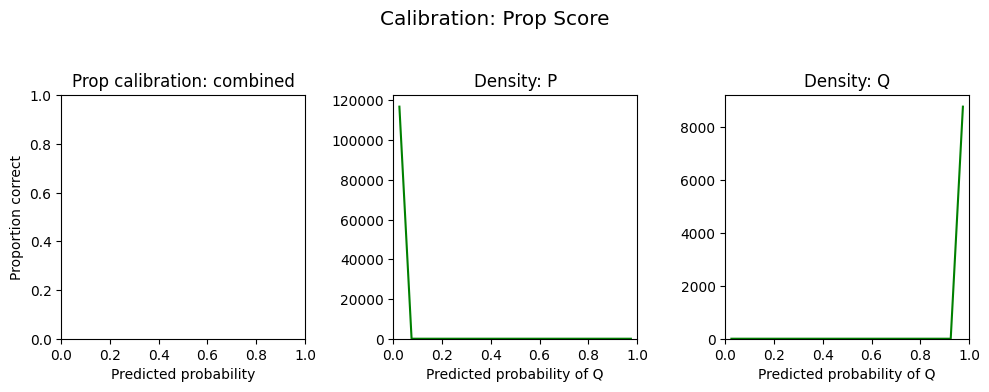

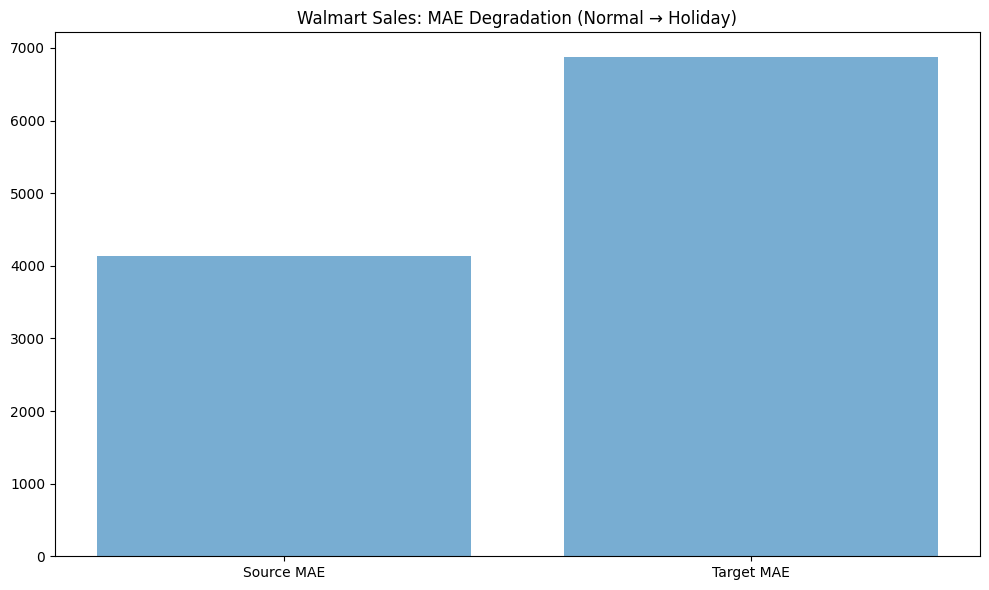

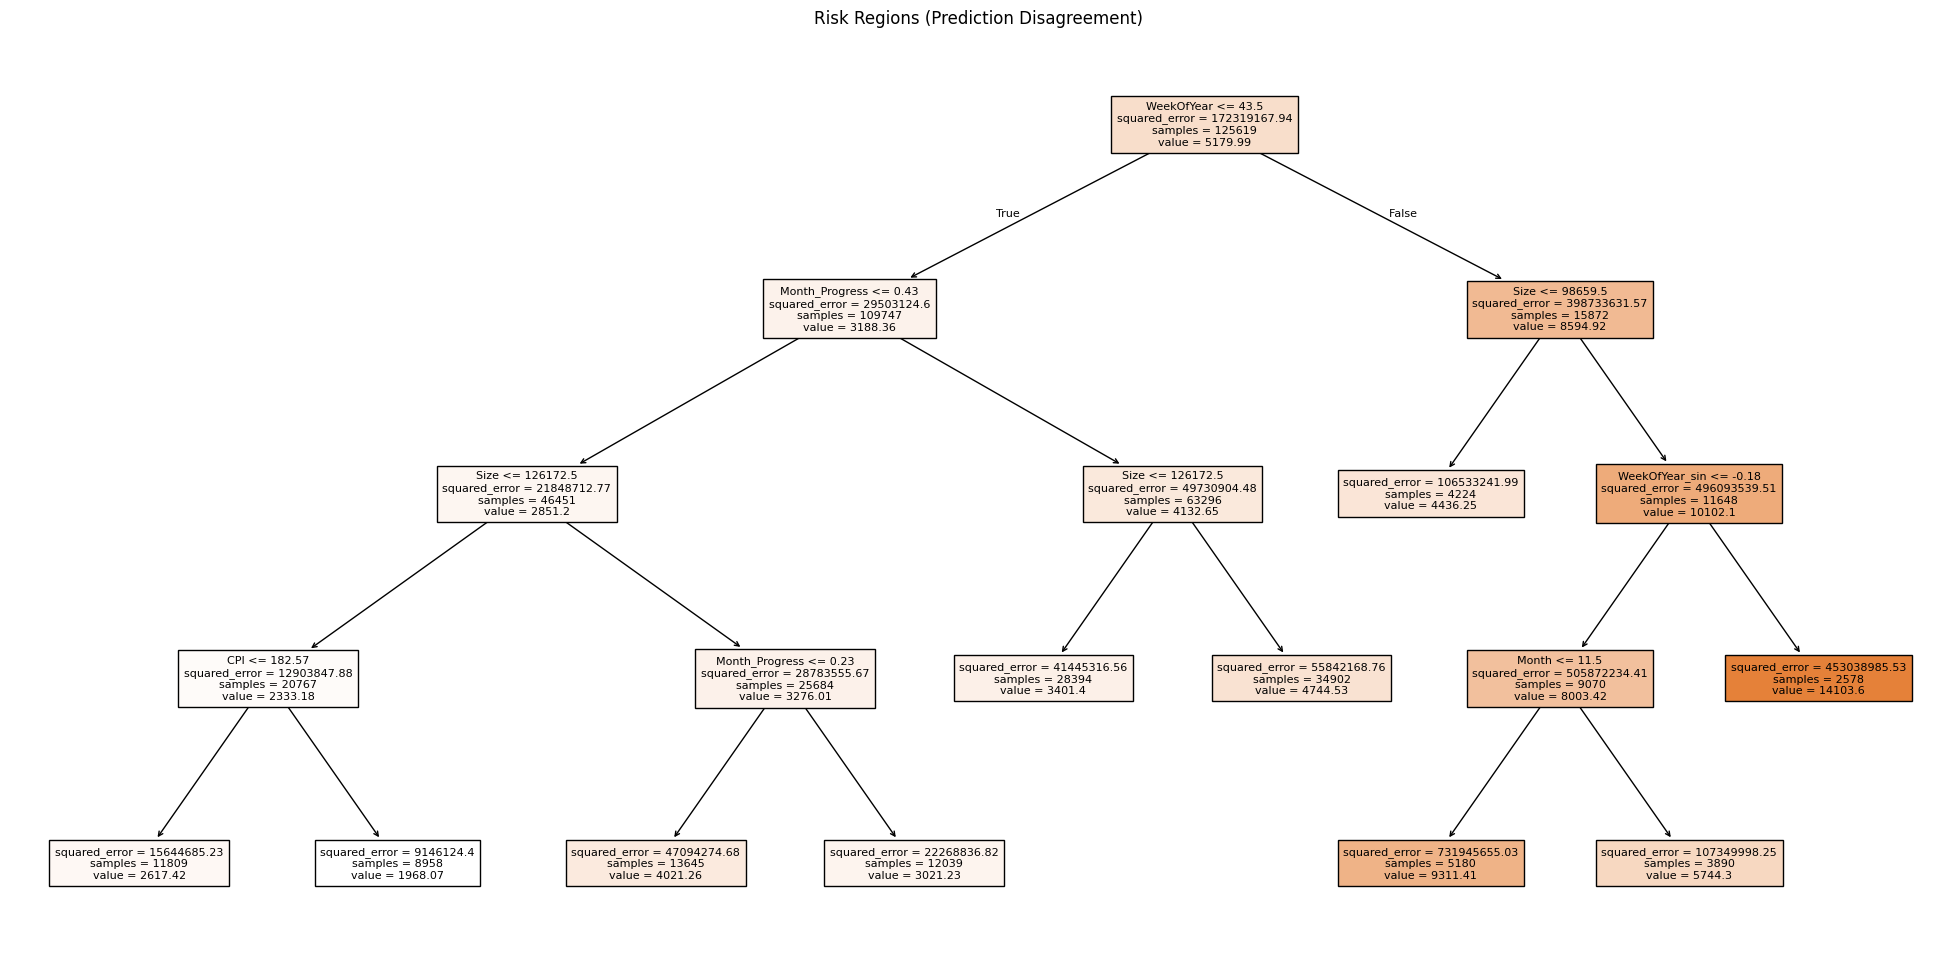

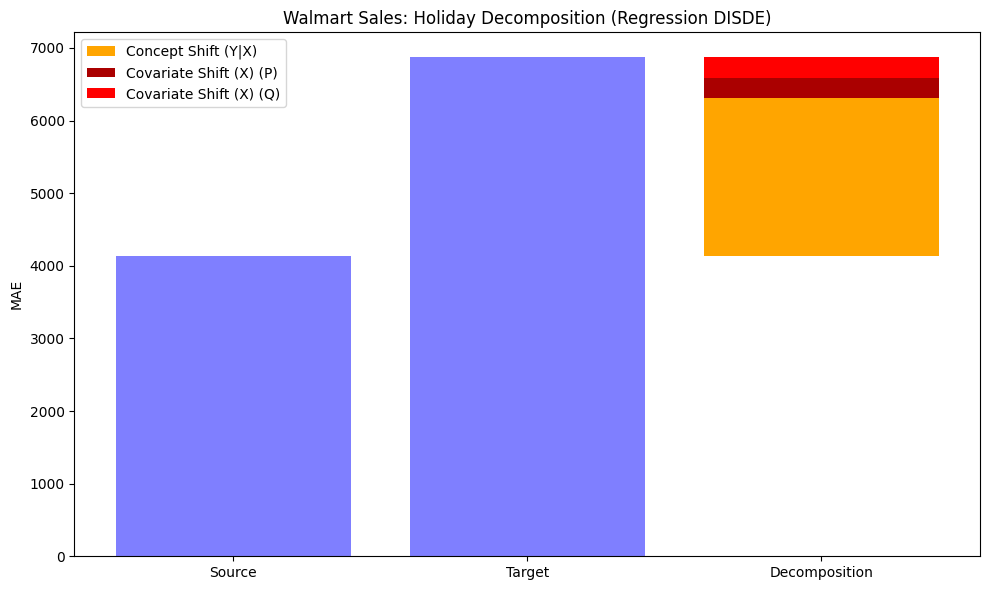

In [6]:
from sklearn.metrics import mean_absolute_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from sklearn.tree import DecisionTreeRegressor, plot_tree
import lightgbm as lgbm
from sklearn.model_selection import KFold
from xgboost import XGBClassifier
CSV_PATH = r"D:\walmart_dataset\final_data_walmart.csv"

print(">>> Loading Walmart Dataset from CSV...")
df_raw = pd.read_csv(CSV_PATH)


df_raw.columns = df_raw.columns.str.strip()
means = df_raw.groupby("IsHoliday")["Weekly_Sales"].mean()
std = df_raw.groupby("IsHoliday")["Weekly_Sales"].std()
print(means)
print(std)

cols_to_encode = ['Store', 'weather_condition', 'city', 'Dept', 'Type']
df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)

# Source Domain: Normal Days (In-Distribution)
# Target Domain: Holidays (Out-of-Distribution)
source_df = df_encoded[df_encoded['IsHoliday'] == 0].copy()
target_df = df_encoded[df_encoded['IsHoliday'] == 1].copy()

# Define feature columns (exclude target, proxies, and the splitting variable)
drop_cols = [
    'Weekly_Sales', 'Date',
    'IsHoliday','holiday_proximity','is_near_holiday','holiday_weight','Is_Christmas_Season','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
    ,'Month','WeekOfYear',
    'Quarter','Season','Year_Progress','Month_Progress','WeekOfYear_sin','WeekOfYear_cos','Month_sin','Month_cos','Season_sin','Season_cos','Is_Month_Start',
    'Is_Month_End','DayOfWeek','DayOfWeek_sin','DayOfWeek_cos',
]
feature_names = [c for c in source_df.columns if c not in drop_cols]

X_source_full = source_df[feature_names].values
y_source_full = source_df['Weekly_Sales'].values

X_target = target_df[feature_names].values
y_target = target_df['Weekly_Sales'].values

np.random.seed(42)
perm = np.random.permutation(len(X_source_full))
train_source = perm[:int(0.7 * len(X_source_full))]
id_test_source = perm[int(0.7 * len(X_source_full)):]

X_source_train = X_source_full[train_source]
y_source_train = y_source_full[train_source]

X_source_test = X_source_full[id_test_source]
y_source_test = y_source_full[id_test_source]

print(f"Features: {len(feature_names)}")


np.random.seed(42)
perm = np.random.permutation(len(X_target))
train_target = perm[:int(0.7 * len(X_target))]
id_test_target = perm[int(0.7 * len(X_target)):]

X_train_target = X_target[train_target]
y_train_target = y_target[train_target]

X_target_test = X_target[id_test_target]
y_target_test = y_target[id_test_target]
print(f"Source test: {len(X_source_test)} | Target: {len(X_target_test)}")
print("\n>>> Training LGBM Regressor...")
model = lgbm.LGBMRegressor()
model.fit(X_source_train, y_source_train)



def degradation_decomp_regression(
    source_X,
    source_y,
    target_X_raw,
    target_y_raw,
    model,
    data_sum=20000,
    K=8,
    domain_classifier=None,draw_calibration=False, save_calibration_png='calibration.png'
):

    perm1 = np.random.permutation(target_X_raw.shape[0])
    target_X = target_X_raw[perm1[:data_sum], :]
    target_y = target_y_raw[perm1[:data_sum]]


    piA = np.zeros(source_X.shape[0])
    piB = np.zeros(target_X.shape[0])

    permA = np.random.permutation(source_X.shape[0])
    permB = np.random.permutation(target_X.shape[0])

    kf = KFold(n_splits=K, shuffle=False)

    A_train_index_list, A_test_index_list = [], []
    B_train_index_list, B_test_index_list = [], []

    for train_idx, test_idx in kf.split(source_X):
        A_train_index_list.append(train_idx)
        A_test_index_list.append(test_idx)

    for train_idx, test_idx in kf.split(target_X):
        B_train_index_list.append(train_idx)
        B_test_index_list.append(test_idx)

    for i in range(K):
        trainX = np.concatenate([
            source_X[permA[A_train_index_list[i]]],
            target_X[permB[B_train_index_list[i]]]
        ], axis=0)

        trainT = np.zeros(trainX.shape[0])
        trainT[len(A_train_index_list[i]):] = 1.0

        if domain_classifier is None:
            clf = XGBClassifier(random_state=0)
        else:
            clf = domain_classifier

        clf.fit(trainX, trainT)

        piA[permA[A_test_index_list[i]]] = clf.predict_proba(
            source_X[permA[A_test_index_list[i]]]
        )[:, 1]

        piB[permB[B_test_index_list[i]]] = clf.predict_proba(
            target_X[permB[B_test_index_list[i]]]
        )[:, 1]

    if draw_calibration:
        plot_calibration(piA, piB, save_dir=save_calibration_png)
    alpha = target_X.shape[0] / (source_X.shape[0] + target_X.shape[0])

    wA = piA / ((1 - alpha) * piA + alpha * (1 - piA))
    wB = (1 - piB) / ((1 - alpha) * piB + alpha * (1 - piB))

    wA /= np.sum(wA)
    wB /= np.sum(wB)


    pred_source = model.predict(source_X)
    pred_target = model.predict(target_X)

    loss_source = np.abs(pred_source - source_y)
    loss_target = np.abs(pred_target - target_y)

    # empirical risks
    errorA = np.mean(loss_source)
    errorB = np.mean(loss_target)

    # weighted risks
    sx_A = np.dot(wA, loss_source)
    sx_B = np.dot(wB, loss_target)

    return errorA,errorB,sx_A,sx_B

def plot_calibration(prop_p, prop_q, nbins=20, p_weights=None, q_weights=None,
                     nanmask_threshold=0.01, name='Prop Score',
                     save_dir='.', balance=False):

    fig,ax=plt.subplots(1,3,figsize=(10,4))
    for i in range(3):
        ax[i].set_box_aspect(1)
        ax[i].set_xlim(0,1)
    fig.suptitle("Calibration: {}".format(name), fontsize="x-large")

    if p_weights is None: p_weights = np.ones_like(prop_p)
    if q_weights is None: q_weights = np.ones_like(prop_q)

    p_sample_weights = p_weights.copy()
    q_sample_weights = q_weights.copy()
    if balance:
        p_sample_weights = p_sample_weights / p_sample_weights.sum()
        q_sample_weights = q_sample_weights / q_sample_weights.sum()

    conf_scores, bin_edges = np.histogram(np.concatenate([1-prop_p, prop_q]),bins=nbins, density=True,
                                          weights=np.concatenate([p_sample_weights,
                                                                 q_sample_weights]),
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2

    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)
    # print(bin_mids)
    # print(nanmask * conf_scores / (conf_scores + conf_scores[::-1]))
    ax[0].plot(bin_mids, nanmask * conf_scores / (conf_scores + conf_scores[::-1]), color='green')
    ax[0].set_ylim(0,1)
    ax[0].set_ylabel('Proportion correct')
    ax[0].set_xlabel('Predicted probability')
    ax[0].set_title('Prop calibration: combined')

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_p]),bins=nbins, weights=p_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[1].plot(bin_mids, conf_scores, color='green')
    ax[1].set_title('Density: P')
    ax[1].set_xlabel('Predicted probability of Q')
    ax[1].set_ylim(bottom=0)

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_q]),bins=nbins, weights=q_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[2].plot(bin_mids, conf_scores, color='green')
    ax[2].set_title('Density: Q')
    ax[2].set_xlabel('Predicted probability of Q')
    ax[2].set_ylim(bottom=0)

    fig.tight_layout()
    if save_dir is not None:
        plt.savefig(save_dir)

print("\n>>> Running Regression DISDE...")
reg_domain_classifier = lgbm.LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    use_label_encoder=False,
    eval_metric='logloss'
)
p2p, q2q, p2s, s2q = degradation_decomp_regression(
    X_source_test, y_source_test,
    X_target_test, y_target_test,
    model, data_sum=20000, domain_classifier = reg_domain_classifier, K=8,draw_calibration=True, save_calibration_png='hol_regression_calibration.png'
)



total_degradation = q2q - p2p
yx_shift = s2q - p2s
x_shift_P = p2s - p2p
x_shift_Q = q2q - s2q
total_x_shift = x_shift_P + x_shift_Q


print("-"*50)
print(f"Source MAE (p2p): {p2p:.4f}")
print(f"Target MAE (q2q): {q2q:.4f}")
print(f"p2s: expected Source Error on Sx (Reweighted Source Error)  : {p2s:.4f}")
print(f"s2q: expected Target Error on Sx (Reweighted Target Error)  : {s2q:.4f}")
print(f"Total Degradation: {total_degradation:.4f}")
print(f"Y|X Shift: {yx_shift:.4f}")
print(f"X Shift (P side): {x_shift_P:.4f}")
print(f"X Shift (Q side): {x_shift_Q:.4f}")
print(f"Total X Shift : {total_x_shift:.4f}")
print(f"X Shift P side ratio: {x_shift_P/total_degradation:.4f}")
print(f"X Shift Q side ratio: {x_shift_Q/total_degradation:.4f}")
print(f"X Shift Ratio : {total_x_shift/total_degradation:.4f}")
print(f"Y|X Shift Ratio: {yx_shift/total_degradation:.4f}")
print("-"*50)

from whyshift.region_analysis import shared_reweight

wA, wB, new_X, new_weights = shared_reweight(X_source_test, X_target_test, K=8)

# Train separate regressors
lgb_params = {
    'n_estimators': 300,
    'learning_rate': 0.1,
    'num_leaves': 62,
    'max_depth': 20,
    'verbose': -1,
    'n_jobs': 1
}
source_model = lgbm.LGBMRegressor(**lgb_params)
target_model = lgbm.LGBMRegressor(**lgb_params)

source_model.fit(X_source_train, y_source_train, sample_weight=wA)
target_model.fit(X_train_target, y_train_target, sample_weight=wB)

# Disagreement in predictions
pred_src = source_model.predict(new_X)
pred_tgt = target_model.predict(new_X)

new_Y = np.abs(pred_src - pred_tgt)
print("\n>>> Model MAE Comparison:")

# Source model
print(f"Source model MAE on ID test:  {mean_absolute_error(y_source_test, source_model.predict(X_source_test)):.4f}")
print(f"Source model MAE on OOD test: {mean_absolute_error(y_target, source_model.predict(X_target_test)):.4f}")

# Target model
print(f"Target model MAE on ID test:  {mean_absolute_error(y_source_test, target_model.predict(X_source_test)):.4f}")
print(f"Target model MAE on OOD test: {mean_absolute_error(y_target, target_model.predict(X_target_test)):.4f}")
region_tree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=100,
    min_weight_fraction_leaf=0.05
)

region_tree.fit(new_X, new_Y, sample_weight=new_weights)



fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(["Source MAE", "Target MAE"], [p2p, q2q], alpha=0.6)
ax.set_title("Walmart Sales: MAE Degradation (Normal → Holiday)")
plt.tight_layout()
plt.savefig("walmart_regression_hol_decomposition.png")
plt.show()

# Risk Tree
plt.figure(figsize=(25, 12))
plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=8,precision = 2 )
plt.title("Risk Regions (Prediction Disagreement)")
plt.savefig("walmart_regression_risk_hol_tree.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

base_val = min(p2p, q2q)
max_val = max(p2p, q2q)
gap = max_val - base_val

shift_y = abs(p2s - s2q)
shift_p = abs(p2p - p2s)
shift_q = abs(s2q - q2q)
total_shift = shift_y + shift_p + shift_q + 1e-9 #

norm_y = (shift_y / total_shift) * gap
norm_p = (shift_p / total_shift) * gap
norm_q = (shift_q / total_shift) * gap

ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)

#ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)

ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")

ax.set_title("Walmart Sales: Holiday Decomposition (Regression DISDE)")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.savefig('walmart_regression_hol_decomposition_bar.png')
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from sklearn.tree import DecisionTreeRegressor, plot_tree
import lightgbm as lgbm
from whyshift.region_analysis import shared_reweight
from xgboost import XGBClassifier
from sklearn.model_selection import KFold


CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"

print(">>> Loading Walmart Dataset from CSV...")
df_raw = pd.read_csv(CSV_PATH)

df_raw.columns = df_raw.columns.str.strip()
stores_ab = df_raw[df_raw['Type'].isin(['A','B'])]['Weekly_Sales']
mean_ab = stores_ab.mean()
std_ab = stores_ab.std()

stores_c = df_raw[df_raw['Type'] == 'C']['Weekly_Sales']
mean_c = stores_c.mean()
std_c = stores_c.std()

print("Stores A & B -> mean:", mean_ab, ", std:", std_ab)
print("Store C -> mean:", mean_c, ", std:", std_c)
cols_to_encode = ['weather_condition','Quarter']
df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)

# Source Domain: Store Types A and B (In-Distribution)
# Target Domain: Store Type C (Out-of-Distribution)
source_df = df_encoded[df_encoded['Type'].isin(['C'])].copy()
target_df = df_encoded[df_encoded['Type'].isin(['A','B'])].copy()


drop_cols = [
    'Weekly_Sales', 'Date', 'Type',
    'Dept','Size','Store','latitude', 'longitude','Size','city','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5','CPI', 'Unemployment', 'Fuel_Price',
]

feature_names = [c for c in source_df.columns if c not in drop_cols]

X_source_full = source_df[feature_names].values
y_source_full = source_df['Weekly_Sales'].values
X_target = target_df[feature_names].values
y_target = target_df['Weekly_Sales'].values

np.random.seed(42)
perm = np.random.permutation(len(X_source_full))
train_idx = perm[:int(0.7*len(X_source_full))]
id_test_idx = perm[int(0.7*len(X_source_full)):]

X_source_train = X_source_full[train_idx]
y_source_train = y_source_full[train_idx]
X_source_test, y_source_test = X_source_full[id_test_idx], y_source_full[id_test_idx]

print(f"Features: {len(feature_names)}")
np.random.seed(42)
perm = np.random.permutation(len(X_target))
train_target = perm[:int(0.7 * len(X_target))]
id_test_target = perm[int(0.7 * len(X_target)):]

X_train_target = X_target[train_target]
y_train_target = y_target[train_target]

X_target_test = X_target[id_test_target]
y_target_test = y_target[id_test_target]
print(f"Source test: {len(X_source_test)} | Target: {len(X_target_test)}")

print("\n>>> Training LGBM Regressor...")
model = lgbm.LGBMRegressor()
model.fit(X_source_train, y_source_train)

def degradation_decomp_regression(
    source_X,
    source_y,
    target_X_raw,
    target_y_raw,
    model,
    data_sum=20000,
    K=8,
    domain_classifier=None,draw_calibration=False, save_calibration_png='calibration.png'
):

    perm1 = np.random.permutation(target_X_raw.shape[0])
    target_X = target_X_raw[perm1[:data_sum], :]
    target_y = target_y_raw[perm1[:data_sum]]


    piA = np.zeros(source_X.shape[0])
    piB = np.zeros(target_X.shape[0])

    permA = np.random.permutation(source_X.shape[0])
    permB = np.random.permutation(target_X.shape[0])

    kf = KFold(n_splits=K, shuffle=False)

    A_train_index_list, A_test_index_list = [], []
    B_train_index_list, B_test_index_list = [], []

    for train_idx, test_idx in kf.split(source_X):
        A_train_index_list.append(train_idx)
        A_test_index_list.append(test_idx)

    for train_idx, test_idx in kf.split(target_X):
        B_train_index_list.append(train_idx)
        B_test_index_list.append(test_idx)

    for i in range(K):
        trainX = np.concatenate([
            source_X[permA[A_train_index_list[i]]],
            target_X[permB[B_train_index_list[i]]]
        ], axis=0)

        trainT = np.zeros(trainX.shape[0])
        trainT[len(A_train_index_list[i]):] = 1.0

        if domain_classifier is None:
            clf = XGBClassifier(random_state=0)
        else:
            clf = domain_classifier

        clf.fit(trainX, trainT)

        piA[permA[A_test_index_list[i]]] = clf.predict_proba(
            source_X[permA[A_test_index_list[i]]]
        )[:, 1]

        piB[permB[B_test_index_list[i]]] = clf.predict_proba(
            target_X[permB[B_test_index_list[i]]]
        )[:, 1]

    if draw_calibration:
        plot_calibration(piA, piB, save_dir=save_calibration_png)
    alpha = target_X.shape[0] / (source_X.shape[0] + target_X.shape[0])

    wA = piA / ((1 - alpha) * piA + alpha * (1 - piA))
    wB = (1 - piB) / ((1 - alpha) * piB + alpha * (1 - piB))

    wA /= np.sum(wA)
    wB /= np.sum(wB)


    pred_source = model.predict(source_X)
    pred_target = model.predict(target_X)

    loss_source = np.abs(pred_source - source_y)
    loss_target = np.abs(pred_target - target_y)

    # empirical risks
    errorA = np.mean(loss_source)
    errorB = np.mean(loss_target)

    # weighted risks
    sx_A = np.dot(wA, loss_source)
    sx_B = np.dot(wB, loss_target)

    return errorA,errorB,sx_A,sx_B

def plot_calibration(prop_p, prop_q, nbins=20, p_weights=None, q_weights=None,
                     nanmask_threshold=0.01, name='Prop Score',
                     save_dir='.', balance=False):

    fig,ax=plt.subplots(1,3,figsize=(10,4))
    for i in range(3):
        ax[i].set_box_aspect(1)
        ax[i].set_xlim(0,1)
    fig.suptitle("Calibration: {}".format(name), fontsize="x-large")

    if p_weights is None: p_weights = np.ones_like(prop_p)
    if q_weights is None: q_weights = np.ones_like(prop_q)

    p_sample_weights = p_weights.copy()
    q_sample_weights = q_weights.copy()
    if balance:
        p_sample_weights = p_sample_weights / p_sample_weights.sum()
        q_sample_weights = q_sample_weights / q_sample_weights.sum()

    conf_scores, bin_edges = np.histogram(np.concatenate([1-prop_p, prop_q]),bins=nbins, density=True,
                                          weights=np.concatenate([p_sample_weights,
                                                                 q_sample_weights]),
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2

    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)
    # print(bin_mids)
    # print(nanmask * conf_scores / (conf_scores + conf_scores[::-1]))
    ax[0].plot(bin_mids, nanmask * conf_scores / (conf_scores + conf_scores[::-1]), color='green')
    ax[0].set_ylim(0,1)
    ax[0].set_ylabel('Proportion correct')
    ax[0].set_xlabel('Predicted probability')
    ax[0].set_title('Prop calibration: combined')

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_p]),bins=nbins, weights=p_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[1].plot(bin_mids, conf_scores, color='green')
    ax[1].set_title('Density: P')
    ax[1].set_xlabel('Predicted probability of Q')
    ax[1].set_ylim(bottom=0)

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_q]),bins=nbins, weights=q_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[2].plot(bin_mids, conf_scores, color='green')
    ax[2].set_title('Density: Q')
    ax[2].set_xlabel('Predicted probability of Q')
    ax[2].set_ylim(bottom=0)

    fig.tight_layout()
    if save_dir is not None:
        plt.savefig(save_dir)

print("\n>>> Running Regression DISDE...")
reg_domain_classifier = lgbm.LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    use_label_encoder=False,
    eval_metric='logloss'
)
p2p, q2q, p2s, s2q = degradation_decomp_regression(
    X_source_full, y_source_full,
    X_target, y_target,
    model, data_sum=20000,domain_classifier=reg_domain_classifier, K=8,draw_calibration=True, save_calibration_png='store_type_regression_calibration.png'
)

total_degradation = q2q - p2p
yx_shift = s2q - p2s
x_shift_P = p2s - p2p
x_shift_Q = q2q - s2q
total_x_shift = x_shift_P + x_shift_Q

print("-"*50)
print(f"Source MAE (p2p): {p2p:.4f}")
print(f"Target MAE (q2q): {q2q:.4f}")
print(f"p2s: expected Source Error on Sx (Reweighted Source Error)  : {p2s:.4f}")
print(f"s2q: expected Target Error on Sx (Reweighted Target Error)  : {s2q:.4f}")
print(f"Total Degradation: {total_degradation:.4f}")
print(f"Y|X Shift: {yx_shift:.4f}")
print(f"X Shift (P side): {x_shift_P:.4f}")
print(f"X Shift (Q side): {x_shift_Q:.4f}")
print(f"Total X Shift : {total_x_shift:.4f}")
print(f"X Shift P side ratio: {x_shift_P/total_degradation:.4f}")
print(f"X Shift Q side ratio: {x_shift_Q/total_degradation:.4f}")
print(f"X Shift Ratio : {total_x_shift/total_degradation:.4f}")
print(f"Y|X Shift Ratio: {yx_shift/total_degradation:.4f}")
print("-"*50)

wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)

source_model = lgbm.LGBMRegressor(**lgb_params)
target_model = lgbm.LGBMRegressor(**lgb_params)

source_model.fit(X_source_train, y_source_train, sample_weight=wA)
target_model.fit(X_train_target, y_train_target, sample_weight=wB)

pred_src = source_model.predict(new_X)
pred_tgt = target_model.predict(new_X)
new_Y = np.abs(pred_src - pred_tgt)
print("\n>>> Model MAE Comparison:")

# Source model
print(f"Source model MAE on ID test:  {mean_absolute_error(y_source_test, source_model.predict(X_source_test)):.4f}")
print(f"Source model MAE on OOD test: {mean_absolute_error(y_target_test, source_model.predict(X_target_test)):.4f}")

# Target model
print(f"Target model MAE on ID test:  {mean_absolute_error(y_source_test, target_model.predict(X_source_test)):.4f}")
print(f"Target model MAE on OOD test: {mean_absolute_error(y_target_test, target_model.predict(X_target_test)):.4f}")
region_tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, min_weight_fraction_leaf=0.05)
region_tree.fit(new_X, new_Y, sample_weight=new_weights)


fig, ax = plt.subplots(figsize=(10, 6))

base_val = min(p2p, q2q)
max_val = max(p2p, q2q)
gap = max_val - base_val

shift_y = abs(p2s - s2q)
shift_p = abs(p2p - p2s)
shift_q = abs(s2q - q2q)
total_shift = shift_y + shift_p + shift_q + 1e-9 #

norm_y = (shift_y / total_shift) * gap
norm_p = (shift_p / total_shift) * gap
norm_q = (shift_q / total_shift) * gap

ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)

#ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)

ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
ax.set_title("Walmart Sales: Store-Type Decomposition (Regression DISDE)")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.savefig('walmart_regression_type_decomposition.png')
plt.show()

plt.figure(figsize=(25,12))
plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10)
plt.title("Risk Regions (Prediction Disagreement) - Store-Type Regression")
plt.savefig('walmart_regression_risk_tree_type.png', bbox_inches='tight')
plt.show()



In [ ]:
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from sklearn.tree import DecisionTreeRegressor, plot_tree
import lightgbm as lgbm
from whyshift import fetch_model
from whyshift.region_analysis import shared_reweight
from sklearn.model_selection import KFold


CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"

print(">>> Loading Walmart Dataset from CSV...")
df_raw = pd.read_csv(CSV_PATH)

df_raw.columns = df_raw.columns.str.strip()
seasons_124 = df_raw[df_raw['Season'].isin([1,2,4])]['Weekly_Sales']
mean_124 = seasons_124.mean()
std_124 = seasons_124.std()

seasons_3 = df_raw[df_raw['Season'] == 3]['Weekly_Sales']
mean_3 = seasons_3.mean()
std_3 = seasons_3.std()

print("Season 1,2,4 -> mean:", mean_124, ", std:", std_124)
print("Season 3 -> mean:", mean_3, ", std:", std_3)
# Manual One-Hot Encoding
cols_to_encode = ['city', 'Type','Dept', 'Store']
df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)


source_df = df_encoded[df_encoded['Season'].isin([1, 2,4])].copy()
target_df = df_encoded[df_encoded['Season'].isin([3])].copy()

drop_cols = [
    'Weekly_Sales', 'Date', 'Season','Month','Quarter','Month_sin','Month_cos','Is_Summer','WeekOfYear','WeekOfYear_sin','WeekOfYear_cos','Temperature','weather_condition','Year_Progress','Season_sin','Season_cos', 'Is_Christmas_Season','wind_speed','humidity','precipitation','temperature_max','temperature_min',
]

feature_names = [c for c in source_df.columns if c not in drop_cols]

X_source_full = source_df[feature_names].values
y_source_full = source_df['Weekly_Sales'].values
X_target = target_df[feature_names].values
y_target = target_df['Weekly_Sales'].values

np.random.seed(42)
perm = np.random.permutation(len(X_source_full))
train_idx = perm[:int(0.7*len(X_source_full))]
id_test_idx = perm[int(0.7*len(X_source_full)):]

X_source_train = X_source_full[train_idx]
y_source_train = y_source_full[train_idx]
X_source_test, y_source_test = X_source_full[id_test_idx], y_source_full[id_test_idx]

np.random.seed(42)
perm = np.random.permutation(len(X_target))
train_target = perm[:int(0.7 * len(X_target))]
id_test_target = perm[int(0.7 * len(X_target)):]

X_train_target = X_target[train_target]
y_train_target = y_target[train_target]

X_target_test = X_target[id_test_target]
y_target_test = y_target[id_test_target]
print(f"Source test: {len(X_source_test)} | Target: {len(X_target_test)}")

print("\n>>> Training LGBM Regressor...")
model = lgbm.LGBMRegressor()
model.fit(X_source_train, y_source_train)

def degradation_decomp_regression(
    source_X,
    source_y,
    target_X_raw,
    target_y_raw,
    model,
    data_sum=20000,
    K=8,
    domain_classifier=None,draw_calibration=False, save_calibration_png='calibration.png'
):

    perm1 = np.random.permutation(target_X_raw.shape[0])
    target_X = target_X_raw[perm1[:data_sum], :]
    target_y = target_y_raw[perm1[:data_sum]]


    piA = np.zeros(source_X.shape[0])
    piB = np.zeros(target_X.shape[0])

    permA = np.random.permutation(source_X.shape[0])
    permB = np.random.permutation(target_X.shape[0])

    kf = KFold(n_splits=K, shuffle=False)

    A_train_index_list, A_test_index_list = [], []
    B_train_index_list, B_test_index_list = [], []

    for train_idx, test_idx in kf.split(source_X):
        A_train_index_list.append(train_idx)
        A_test_index_list.append(test_idx)

    for train_idx, test_idx in kf.split(target_X):
        B_train_index_list.append(train_idx)
        B_test_index_list.append(test_idx)

    for i in range(K):
        trainX = np.concatenate([
            source_X[permA[A_train_index_list[i]]],
            target_X[permB[B_train_index_list[i]]]
        ], axis=0)

        trainT = np.zeros(trainX.shape[0])
        trainT[len(A_train_index_list[i]):] = 1.0

        if domain_classifier is None:
            clf = XGBClassifier(random_state=0)
        else:
            clf = domain_classifier

        clf.fit(trainX, trainT)

        piA[permA[A_test_index_list[i]]] = clf.predict_proba(
            source_X[permA[A_test_index_list[i]]]
        )[:, 1]

        piB[permB[B_test_index_list[i]]] = clf.predict_proba(
            target_X[permB[B_test_index_list[i]]]
        )[:, 1]

    if draw_calibration:
        plot_calibration(piA, piB, save_dir=save_calibration_png)
    alpha = target_X.shape[0] / (source_X.shape[0] + target_X.shape[0])

    wA = piA / ((1 - alpha) * piA + alpha * (1 - piA))
    wB = (1 - piB) / ((1 - alpha) * piB + alpha * (1 - piB))

    wA /= np.sum(wA)
    wB /= np.sum(wB)


    pred_source = model.predict(source_X)
    pred_target = model.predict(target_X)

    loss_source = np.abs(pred_source - source_y)
    loss_target = np.abs(pred_target - target_y)

    # empirical risks
    errorA = np.mean(loss_source)
    errorB = np.mean(loss_target)

    # weighted risks
    sx_A = np.dot(wA, loss_source)
    sx_B = np.dot(wB, loss_target)

    return errorA,errorB,sx_A,sx_B

def plot_calibration(prop_p, prop_q, nbins=20, p_weights=None, q_weights=None,
                     nanmask_threshold=0.01, name='Prop Score',
                     save_dir='.', balance=False):

    fig,ax=plt.subplots(1,3,figsize=(10,4))
    for i in range(3):
        ax[i].set_box_aspect(1)
        ax[i].set_xlim(0,1)
    fig.suptitle("Calibration: {}".format(name), fontsize="x-large")

    if p_weights is None: p_weights = np.ones_like(prop_p)
    if q_weights is None: q_weights = np.ones_like(prop_q)

    p_sample_weights = p_weights.copy()
    q_sample_weights = q_weights.copy()
    if balance:
        p_sample_weights = p_sample_weights / p_sample_weights.sum()
        q_sample_weights = q_sample_weights / q_sample_weights.sum()

    conf_scores, bin_edges = np.histogram(np.concatenate([1-prop_p, prop_q]),bins=nbins, density=True,
                                          weights=np.concatenate([p_sample_weights,
                                                                 q_sample_weights]),
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2

    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)
    # print(bin_mids)
    # print(nanmask * conf_scores / (conf_scores + conf_scores[::-1]))
    ax[0].plot(bin_mids, nanmask * conf_scores / (conf_scores + conf_scores[::-1]), color='green')
    ax[0].set_ylim(0,1)
    ax[0].set_ylabel('Proportion correct')
    ax[0].set_xlabel('Predicted probability')
    ax[0].set_title('Prop calibration: combined')

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_p]),bins=nbins, weights=p_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[1].plot(bin_mids, conf_scores, color='green')
    ax[1].set_title('Density: P')
    ax[1].set_xlabel('Predicted probability of Q')
    ax[1].set_ylim(bottom=0)

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_q]),bins=nbins, weights=q_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[2].plot(bin_mids, conf_scores, color='green')
    ax[2].set_title('Density: Q')
    ax[2].set_xlabel('Predicted probability of Q')
    ax[2].set_ylim(bottom=0)

    fig.tight_layout()
    if save_dir is not None:
        plt.savefig(save_dir)

print("\n>>> Running Regression DISDE...")
reg_domain_classifier = lgbm.LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    use_label_encoder=False,
    eval_metric='logloss'
)
p2p, q2q, p2s, s2q = degradation_decomp_regression(
    X_source_full, y_source_full,
    X_target, y_target,
    model, data_sum=20000,domain_classifier=reg_domain_classifier, K=8,draw_calibration=True, save_calibration_png='season_regression_calibration.png'
)

total_degradation = q2q - p2p
yx_shift = s2q - p2s
x_shift_P = p2s - p2p
x_shift_Q = q2q - s2q
total_x_shift = x_shift_P + x_shift_Q

print("-"*50)
print(f"Source MAE (p2p): {p2p:.4f}")
print(f"Target MAE (q2q): {q2q:.4f}")
print(f"p2s: expected Source Error on Sx (Reweighted Source Error)  : {p2s:.4f}")
print(f"s2q: expected Target Error on Sx (Reweighted Target Error)  : {s2q:.4f}")
print(f"Total Degradation: {total_degradation:.4f}")
print(f"Y|X Shift: {yx_shift:.4f}")
print(f"X Shift (P side): {x_shift_P:.4f}")
print(f"X Shift (Q side): {x_shift_Q:.4f}")
print(f"Total X Shift : {total_x_shift:.4f}")
print(f"X Shift P side ratio: {x_shift_P/total_degradation:.4f}")
print(f"X Shift Q side ratio: {x_shift_Q/total_degradation:.4f}")
print(f"X Shift Ratio : {total_x_shift/total_degradation:.4f}")
print(f"Y|X Shift Ratio: {yx_shift/total_degradation:.4f}")
print("-"*50)

wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)

source_model = lgbm.LGBMRegressor(**lgb_params)
target_model = lgbm.LGBMRegressor(**lgb_params)

source_model.fit(X_source_train, y_source_train, sample_weight=wA)
target_model.fit(X_train_target, y_train_target, sample_weight=wB)

pred_src = source_model.predict(new_X)
pred_tgt = target_model.predict(new_X)
new_Y = np.abs(pred_src - pred_tgt)

print("\n>>> Model MAE Comparison:")

# Source model
print(f"Source model MAE on ID test:  {mean_absolute_error(y_source_test, source_model.predict(X_source_test)):.4f}")
print(f"Source model MAE on OOD test: {mean_absolute_error(y_target_test, source_model.predict(X_target_test)):.4f}")

# Target model
print(f"Target model MAE on ID test:  {mean_absolute_error(y_source_test, target_model.predict(X_source_test)):.4f}")
print(f"Target model MAE on OOD test: {mean_absolute_error(y_target_test, target_model.predict(X_target_test)):.4f}")

region_tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, min_weight_fraction_leaf=0.05)
region_tree.fit(new_X, new_Y, sample_weight=new_weights)


fig, ax = plt.subplots(figsize=(10, 6))

base_val = min(p2p, q2q)
max_val = max(p2p, q2q)
gap = max_val - base_val

shift_y = abs(p2s - s2q)
shift_p = abs(p2p - p2s)
shift_q = abs(s2q - q2q)
total_shift = shift_y + shift_p + shift_q + 1e-9 #

norm_y = (shift_y / total_shift) * gap
norm_p = (shift_p / total_shift) * gap
norm_q = (shift_q / total_shift) * gap

ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)

#ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)

ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
ax.set_title("Walmart Sales: Season Decomposition (Regression DISDE)")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.savefig('walmart_regression_season_decomposition.png')
plt.show()

plt.figure(figsize=(25,12))
plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10)
plt.title("Risk Regions (Prediction Disagreement) - Store-Type Regression")
plt.savefig('walmart_regression_risk_tree_season.png', bbox_inches='tight')
plt.show()


In [ ]:
#STORE - REGRESSION
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from sklearn.tree import DecisionTreeRegressor, plot_tree
import lightgbm as lgbm
from whyshift import fetch_model
from whyshift.region_analysis import shared_reweight
from sklearn.model_selection import KFold


CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"

print(">>> Loading Walmart Dataset from CSV...")
df_raw = pd.read_csv(CSV_PATH)

df_raw.columns = df_raw.columns.str.strip()
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw['Store'] = df_raw['Store'].astype(int)

cols_to_encode = ['weather_condition','Quarter']
df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)

source_df = df_encoded[df_encoded['Store'].between(1, 30)].copy()
target_df = df_encoded[df_encoded['Store'].between(31, 45)].copy()

print("Train Stores:", sorted(source_df['Store'].unique()))
print("Test Stores:", sorted(target_df['Store'].unique()))
mean_src = source_df['Weekly_Sales'].mean()
std_src = source_df['Weekly_Sales'].std()

mean_trg = target_df['Weekly_Sales'].mean()
std_trg = target_df['Weekly_Sales'].std()

print("Stores 1-30 -> mean:", mean_src, ", std:", std_src)
print("Store 31-45 -> mean:", mean_trg, ", std:", std_trg)
drop_cols = [
    'Weekly_Sales',
    'Date',
    'Store',
    'data_source',
    'city',
    'latitude',
    'longitude','Type', 'Size', 'Dept'
]
feature_names = [c for c in source_df.columns if c not in drop_cols]

X_source_full = source_df[feature_names].values
y_source_full = source_df['Weekly_Sales'].values
X_target = target_df[feature_names].values
y_target = target_df['Weekly_Sales'].values

np.random.seed(42)
perm = np.random.permutation(len(X_source_full))
train_idx = perm[:int(0.7*len(X_source_full))]
id_test_idx = perm[int(0.7*len(X_source_full)):]

X_source_train = X_source_full[train_idx]
y_source_train = y_source_full[train_idx]
X_source_test, y_source_test = X_source_full[id_test_idx], y_source_full[id_test_idx]

np.random.seed(42)
perm = np.random.permutation(len(X_target))
train_target = perm[:int(0.7 * len(X_target))]
id_test_target = perm[int(0.7 * len(X_target)):]

X_train_target = X_target[train_target]
y_train_target = y_target[train_target]

X_target_test = X_target[id_test_target]
y_target_test = y_target[id_test_target]
print(f"Source test: {len(X_source_test)} | Target: {len(X_target_test)}")

print("\n>>> Training LGBM Regressor...")
model = lgbm.LGBMRegressor()
model.fit(X_source_train, y_source_train)

def degradation_decomp_regression(
    source_X,
    source_y,
    target_X_raw,
    target_y_raw,
    model,
    data_sum=20000,
    K=8,
    domain_classifier=None,draw_calibration=False, save_calibration_png='calibration.png'
):

    perm1 = np.random.permutation(target_X_raw.shape[0])
    target_X = target_X_raw[perm1[:data_sum], :]
    target_y = target_y_raw[perm1[:data_sum]]


    piA = np.zeros(source_X.shape[0])
    piB = np.zeros(target_X.shape[0])

    permA = np.random.permutation(source_X.shape[0])
    permB = np.random.permutation(target_X.shape[0])

    kf = KFold(n_splits=K, shuffle=False)

    A_train_index_list, A_test_index_list = [], []
    B_train_index_list, B_test_index_list = [], []

    for train_idx, test_idx in kf.split(source_X):
        A_train_index_list.append(train_idx)
        A_test_index_list.append(test_idx)

    for train_idx, test_idx in kf.split(target_X):
        B_train_index_list.append(train_idx)
        B_test_index_list.append(test_idx)

    for i in range(K):
        trainX = np.concatenate([
            source_X[permA[A_train_index_list[i]]],
            target_X[permB[B_train_index_list[i]]]
        ], axis=0)

        trainT = np.zeros(trainX.shape[0])
        trainT[len(A_train_index_list[i]):] = 1.0

        if domain_classifier is None:
            clf = XGBClassifier(random_state=0)
        else:
            clf = domain_classifier

        clf.fit(trainX, trainT)

        piA[permA[A_test_index_list[i]]] = clf.predict_proba(
            source_X[permA[A_test_index_list[i]]]
        )[:, 1]

        piB[permB[B_test_index_list[i]]] = clf.predict_proba(
            target_X[permB[B_test_index_list[i]]]
        )[:, 1]

    if draw_calibration:
        plot_calibration(piA, piB, save_dir=save_calibration_png)
    alpha = target_X.shape[0] / (source_X.shape[0] + target_X.shape[0])

    wA = piA / ((1 - alpha) * piA + alpha * (1 - piA))
    wB = (1 - piB) / ((1 - alpha) * piB + alpha * (1 - piB))

    wA /= np.sum(wA)
    wB /= np.sum(wB)


    pred_source = model.predict(source_X)
    pred_target = model.predict(target_X)

    loss_source = np.abs(pred_source - source_y)
    loss_target = np.abs(pred_target - target_y)

    # empirical risks
    errorA = np.mean(loss_source)
    errorB = np.mean(loss_target)

    # weighted risks
    sx_A = np.dot(wA, loss_source)
    sx_B = np.dot(wB, loss_target)

    return errorA,errorB,sx_A,sx_B

def plot_calibration(prop_p, prop_q, nbins=20, p_weights=None, q_weights=None,
                     nanmask_threshold=0.01, name='Prop Score',
                     save_dir='.', balance=False):

    fig,ax=plt.subplots(1,3,figsize=(10,4))
    for i in range(3):
        ax[i].set_box_aspect(1)
        ax[i].set_xlim(0,1)
    fig.suptitle("Calibration: {}".format(name), fontsize="x-large")

    if p_weights is None: p_weights = np.ones_like(prop_p)
    if q_weights is None: q_weights = np.ones_like(prop_q)

    p_sample_weights = p_weights.copy()
    q_sample_weights = q_weights.copy()
    if balance:
        p_sample_weights = p_sample_weights / p_sample_weights.sum()
        q_sample_weights = q_sample_weights / q_sample_weights.sum()

    conf_scores, bin_edges = np.histogram(np.concatenate([1-prop_p, prop_q]),bins=nbins, density=True,
                                          weights=np.concatenate([p_sample_weights,
                                                                 q_sample_weights]),
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2

    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)
    # print(bin_mids)
    # print(nanmask * conf_scores / (conf_scores + conf_scores[::-1]))
    ax[0].plot(bin_mids, nanmask * conf_scores / (conf_scores + conf_scores[::-1]), color='green')
    ax[0].set_ylim(0,1)
    ax[0].set_ylabel('Proportion correct')
    ax[0].set_xlabel('Predicted probability')
    ax[0].set_title('Prop calibration: combined')

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_p]),bins=nbins, weights=p_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[1].plot(bin_mids, conf_scores, color='green')
    ax[1].set_title('Density: P')
    ax[1].set_xlabel('Predicted probability of Q')
    ax[1].set_ylim(bottom=0)

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_q]),bins=nbins, weights=q_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[2].plot(bin_mids, conf_scores, color='green')
    ax[2].set_title('Density: Q')
    ax[2].set_xlabel('Predicted probability of Q')
    ax[2].set_ylim(bottom=0)

    fig.tight_layout()
    if save_dir is not None:
        plt.savefig(save_dir)

print("\n>>> Running Regression DISDE...")
reg_domain_classifier = lgbm.LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    use_label_encoder=False,
    eval_metric='logloss'
)
p2p, q2q, p2s, s2q = degradation_decomp_regression(
    X_source_full, y_source_full,
    X_target, y_target,
    model, data_sum=20000,domain_classifier=reg_domain_classifier, K=8,draw_calibration=True, save_calibration_png='store_regression_calibration.png'
)

total_degradation = q2q - p2p
yx_shift = s2q - p2s
x_shift_P = p2s - p2p
x_shift_Q = q2q - s2q
total_x_shift = x_shift_P + x_shift_Q

print("-"*50)
print(f"Source MAE (p2p): {p2p:.4f}")
print(f"Target MAE (q2q): {q2q:.4f}")
print(f"p2s: expected Source Error on Sx (Reweighted Source Error)  : {p2s:.4f}")
print(f"s2q: expected Target Error on Sx (Reweighted Target Error)  : {s2q:.4f}")
print(f"Total Degradation: {total_degradation:.4f}")
print(f"Y|X Shift: {yx_shift:.4f}")
print(f"X Shift (P side): {x_shift_P:.4f}")
print(f"X Shift (Q side): {x_shift_Q:.4f}")
print(f"Total X Shift : {total_x_shift:.4f}")
print(f"X Shift P side ratio: {x_shift_P/total_degradation:.4f}")
print(f"X Shift Q side ratio: {x_shift_Q/total_degradation:.4f}")
print(f"X Shift Ratio : {total_x_shift/total_degradation:.4f}")
print(f"Y|X Shift Ratio: {yx_shift/total_degradation:.4f}")
print("-"*50)

wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)

source_model = lgbm.LGBMRegressor(**lgb_params)
target_model = lgbm.LGBMRegressor(**lgb_params)

source_model.fit(X_source_train, y_source_train, sample_weight=wA)
target_model.fit(X_train_target, y_train_target, sample_weight=wB)

pred_src = source_model.predict(new_X)
pred_tgt = target_model.predict(new_X)
new_Y = np.abs(pred_src - pred_tgt)

print("\n>>> Model MAE Comparison:")

# Source model
print(f"Source model MAE on ID test:  {mean_absolute_error(y_source_test, source_model.predict(X_source_test)):.4f}")
print(f"Source model MAE on OOD test: {mean_absolute_error(y_target_test, source_model.predict(X_target_test)):.4f}")

# Target model
print(f"Target model MAE on ID test:  {mean_absolute_error(y_source_test, target_model.predict(X_source_test)):.4f}")
print(f"Target model MAE on OOD test: {mean_absolute_error(y_target_test, target_model.predict(X_target_test)):.4f}")

region_tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, min_weight_fraction_leaf=0.05)
region_tree.fit(new_X, new_Y, sample_weight=new_weights)


fig, ax = plt.subplots(figsize=(10, 6))

base_val = min(p2p, q2q)
max_val = max(p2p, q2q)
gap = max_val - base_val

shift_y = abs(p2s - s2q)
shift_p = abs(p2p - p2s)
shift_q = abs(s2q - q2q)
total_shift = shift_y + shift_p + shift_q + 1e-9 #

norm_y = (shift_y / total_shift) * gap
norm_p = (shift_p / total_shift) * gap
norm_q = (shift_q / total_shift) * gap

ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)

#ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)

ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")
ax.set_title("Walmart Sales: Store Decomposition (Regression DISDE)")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.savefig('walmart_regression_store_decomposition.png')
plt.show()

plt.figure(figsize=(25,12))
plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10)
plt.title("Risk Regions (Prediction Disagreement) - Store Regression")
plt.savefig('walmart_regression_risk_tree_store.png', bbox_inches='tight')
plt.show()


In [ ]:
#CHRISTMAS - REGRESSION
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from sklearn.tree import DecisionTreeRegressor, plot_tree
import lightgbm as lgbm
from sklearn.model_selection import KFold
from xgboost import XGBClassifier
CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"

print(">>> Loading Walmart Dataset from CSV...")
df_raw = pd.read_csv(CSV_PATH)


df_raw.columns = df_raw.columns.str.strip()
means = df_raw.groupby("Is_Christmas_Season")["Weekly_Sales"].mean()
std = df_raw.groupby("Is_Christmas_Season")["Weekly_Sales"].std()
print(means)
print(std)

cols_to_encode = ['Store', 'weather_condition', 'city', 'Dept', 'Type']
df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)

# Source Domain: Normal Days (In-Distribution)
# Target Domain: Holidays (Out-of-Distribution)
source_df = df_encoded[df_encoded['Is_Christmas_Season'] == 0].copy()
target_df = df_encoded[df_encoded['Is_Christmas_Season'] == 1].copy()

# Define feature columns (exclude target, proxies, and the splitting variable)
drop_cols = [
    'Weekly_Sales', 'Date',
    'IsHoliday','holiday_proximity','is_near_holiday','holiday_weight','Is_Christmas_Season','Month','WeekOfYear',
    'Quarter','Season','Year_Progress','Month_Progress','WeekOfYear_sin','WeekOfYear_cos','Month_sin','Month_cos','Season_sin','Season_cos','Is_Month_Start',
    'Is_Month_End','DayOfWeek','DayOfWeek_sin','DayOfWeek_cos','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]


feature_names = [c for c in source_df.columns if c not in drop_cols]

X_source_full = source_df[feature_names].values
y_source_full = source_df['Weekly_Sales'].values

X_target = target_df[feature_names].values
y_target = target_df['Weekly_Sales'].values


np.random.seed(42)
perm = np.random.permutation(len(X_source_full))
train_idx = perm[:int(0.7 * len(X_source_full))]
id_test_idx = perm[int(0.7 * len(X_source_full)):]

X_source_train = X_source_full[train_idx]
y_source_train = y_source_full[train_idx]

X_source_test = X_source_full[id_test_idx]
y_source_test = y_source_full[id_test_idx]

print(f"Features: {len(feature_names)}")
np.random.seed(42)
perm = np.random.permutation(len(X_target))
train_target = perm[:int(0.7 * len(X_target))]
id_test_target = perm[int(0.7 * len(X_target)):]

X_train_target = X_target[train_target]
y_train_target = y_target[train_target]

X_target_test = X_target[id_test_target]
y_target_test = y_target[id_test_target]
print(f"Source test: {len(X_source_test)} | Target: {len(X_target_test)}")

print("\n>>> Training LGBM Regressor...")
model = lgbm.LGBMRegressor()
model.fit(X_source_train, y_source_train)



def degradation_decomp_regression(
    source_X,
    source_y,
    target_X_raw,
    target_y_raw,
    model,
    data_sum=20000,
    K=8,
    domain_classifier=None,draw_calibration=False, save_calibration_png='calibration.png'
):

    perm1 = np.random.permutation(target_X_raw.shape[0])
    target_X = target_X_raw[perm1[:data_sum], :]
    target_y = target_y_raw[perm1[:data_sum]]


    piA = np.zeros(source_X.shape[0])
    piB = np.zeros(target_X.shape[0])

    permA = np.random.permutation(source_X.shape[0])
    permB = np.random.permutation(target_X.shape[0])

    kf = KFold(n_splits=K, shuffle=False)

    A_train_index_list, A_test_index_list = [], []
    B_train_index_list, B_test_index_list = [], []

    for train_idx, test_idx in kf.split(source_X):
        A_train_index_list.append(train_idx)
        A_test_index_list.append(test_idx)

    for train_idx, test_idx in kf.split(target_X):
        B_train_index_list.append(train_idx)
        B_test_index_list.append(test_idx)

    for i in range(K):
        trainX = np.concatenate([
            source_X[permA[A_train_index_list[i]]],
            target_X[permB[B_train_index_list[i]]]
        ], axis=0)

        trainT = np.zeros(trainX.shape[0])
        trainT[len(A_train_index_list[i]):] = 1.0

        if domain_classifier is None:
            clf = XGBClassifier(random_state=0)
        else:
            clf = domain_classifier

        clf.fit(trainX, trainT)

        piA[permA[A_test_index_list[i]]] = clf.predict_proba(
            source_X[permA[A_test_index_list[i]]]
        )[:, 1]

        piB[permB[B_test_index_list[i]]] = clf.predict_proba(
            target_X[permB[B_test_index_list[i]]]
        )[:, 1]

    if draw_calibration:
        plot_calibration(piA, piB, save_dir=save_calibration_png)
    alpha = target_X.shape[0] / (source_X.shape[0] + target_X.shape[0])

    wA = piA / ((1 - alpha) * piA + alpha * (1 - piA))
    wB = (1 - piB) / ((1 - alpha) * piB + alpha * (1 - piB))

    wA /= np.sum(wA)
    wB /= np.sum(wB)


    pred_source = model.predict(source_X)
    pred_target = model.predict(target_X)

    loss_source = np.abs(pred_source - source_y)
    loss_target = np.abs(pred_target - target_y)

    # empirical risks
    errorA = np.mean(loss_source)
    errorB = np.mean(loss_target)

    # weighted risks
    sx_A = np.dot(wA, loss_source)
    sx_B = np.dot(wB, loss_target)

    return errorA,errorB,sx_A,sx_B

def plot_calibration(prop_p, prop_q, nbins=20, p_weights=None, q_weights=None,
                     nanmask_threshold=0.01, name='Prop Score',
                     save_dir='.', balance=False):

    fig,ax=plt.subplots(1,3,figsize=(10,4))
    for i in range(3):
        ax[i].set_box_aspect(1)
        ax[i].set_xlim(0,1)
    fig.suptitle("Calibration: {}".format(name), fontsize="x-large")

    if p_weights is None: p_weights = np.ones_like(prop_p)
    if q_weights is None: q_weights = np.ones_like(prop_q)

    p_sample_weights = p_weights.copy()
    q_sample_weights = q_weights.copy()
    if balance:
        p_sample_weights = p_sample_weights / p_sample_weights.sum()
        q_sample_weights = q_sample_weights / q_sample_weights.sum()

    conf_scores, bin_edges = np.histogram(np.concatenate([1-prop_p, prop_q]),bins=nbins, density=True,
                                          weights=np.concatenate([p_sample_weights,
                                                                 q_sample_weights]),
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2

    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)
    # print(bin_mids)
    # print(nanmask * conf_scores / (conf_scores + conf_scores[::-1]))
    ax[0].plot(bin_mids, nanmask * conf_scores / (conf_scores + conf_scores[::-1]), color='green')
    ax[0].set_ylim(0,1)
    ax[0].set_ylabel('Proportion correct')
    ax[0].set_xlabel('Predicted probability')
    ax[0].set_title('Prop calibration: combined')

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_p]),bins=nbins, weights=p_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[1].plot(bin_mids, conf_scores, color='green')
    ax[1].set_title('Density: P')
    ax[1].set_xlabel('Predicted probability of Q')
    ax[1].set_ylim(bottom=0)

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_q]),bins=nbins, weights=q_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[2].plot(bin_mids, conf_scores, color='green')
    ax[2].set_title('Density: Q')
    ax[2].set_xlabel('Predicted probability of Q')
    ax[2].set_ylim(bottom=0)

    fig.tight_layout()
    if save_dir is not None:
        plt.savefig(save_dir)

print("\n>>> Running Regression DISDE...")
reg_domain_classifier = lgbm.LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    use_label_encoder=False,
    eval_metric='logloss'
)
p2p, q2q, p2s, s2q = degradation_decomp_regression(
    X_source_full, y_source_full,
    X_target, y_target,
    model, data_sum=20000, domain_classifier = reg_domain_classifier, K=8,draw_calibration=True, save_calibration_png='Is_Christmas_Season_regression_calibration.png'
)



total_degradation = q2q - p2p
yx_shift = s2q - p2s
x_shift_P = p2s - p2p
x_shift_Q = q2q - s2q
total_x_shift = x_shift_P + x_shift_Q


print("-"*50)
print(f"Source MAE (p2p): {p2p:.4f}")
print(f"Target MAE (q2q): {q2q:.4f}")
print(f"p2s: expected Source Error on Sx (Reweighted Source Error)  : {p2s:.4f}")
print(f"s2q: expected Target Error on Sx (Reweighted Target Error)  : {s2q:.4f}")
print(f"Total Degradation: {total_degradation:.4f}")
print(f"Y|X Shift: {yx_shift:.4f}")
print(f"X Shift (P side): {x_shift_P:.4f}")
print(f"X Shift (Q side): {x_shift_Q:.4f}")
print(f"Total X Shift : {total_x_shift:.4f}")
print(f"X Shift P side ratio: {x_shift_P/total_degradation:.4f}")
print(f"X Shift Q side ratio: {x_shift_Q/total_degradation:.4f}")
print(f"X Shift Ratio : {total_x_shift/total_degradation:.4f}")
print(f"Y|X Shift Ratio: {yx_shift/total_degradation:.4f}")
print("-"*50)

from whyshift.region_analysis import shared_reweight

wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)

# Train separate regressors
source_model = lgbm.LGBMRegressor(**lgb_params)
target_model = lgbm.LGBMRegressor(**lgb_params)

source_model.fit(X_source_train, y_source_train, sample_weight=wA)
target_model.fit(X_train_target, y_train_target, sample_weight=wB)

# Disagreement in predictions
pred_src = source_model.predict(new_X)
pred_tgt = target_model.predict(new_X)

new_Y = np.abs(pred_src - pred_tgt)

print("\n>>> Model MAE Comparison:")

# Source model
print(f"Source model MAE on ID test:  {mean_absolute_error(y_source_test, source_model.predict(X_source_test)):.4f}")
print(f"Source model MAE on OOD test: {mean_absolute_error(y_target_test, source_model.predict(X_target_test)):.4f}")

# Target model
print(f"Target model MAE on ID test:  {mean_absolute_error(y_source_test, target_model.predict(X_source_test)):.4f}")
print(f"Target model MAE on OOD test: {mean_absolute_error(y_target_test, target_model.predict(X_target_test)):.4f}")
region_tree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=100,
    min_weight_fraction_leaf=0.05
)

region_tree.fit(new_X, new_Y, sample_weight=new_weights)



fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(["Source MAE", "Target MAE"], [p2p, q2q], alpha=0.6)
ax.set_title("Walmart Sales: MAE Degradation (Normal → Holiday)")
plt.tight_layout()
plt.savefig("walmart_regression_Is_Christmas_Season_decomposition.png")
plt.show()

# Risk Tree
plt.figure(figsize=(25, 12))
plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10)
plt.title("Risk Regions (Prediction Disagreement)")
plt.savefig("walmart_regression_risk_Is_Christmas_Season_tree.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

base_val = min(p2p, q2q)
max_val = max(p2p, q2q)
gap = max_val - base_val

shift_y = abs(p2s - s2q)
shift_p = abs(p2p - p2s)
shift_q = abs(s2q - q2q)
total_shift = shift_y + shift_p + shift_q + 1e-9 #

norm_y = (shift_y / total_shift) * gap
norm_p = (shift_p / total_shift) * gap
norm_q = (shift_q / total_shift) * gap

ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)

#ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)

ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")

ax.set_title("Walmart Sales: Christmas Decomposition (Regression DISDE)")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.savefig('walmart_regression_Is_Christmas_Season_decomposition_bar.png')
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import sklearn
from sklearn.tree import DecisionTreeRegressor, plot_tree
import lightgbm as lgbm
from torch.utils.data import TensorDataset, DataLoader, random_split


import torch
import torch.nn.functional as F
from whyshift.methods.model_family import MLP


# Path to your specific Walmart CSV file
CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"

# Add path to the whyshift library
sys.path.append("D:/tableshift")
from whyshift import degradation_decomp, fetch_model
from whyshift.region_analysis import shared_reweight

print(">>> Loading Walmart Dataset from CSV...")
df_raw = pd.read_csv(CSV_PATH)


df_raw.columns = df_raw.columns.str.strip()
# Define domains based on city
source_cities = ['Houston', 'Philadelphia', 'Phoenix', 'San Jose', 'Jacksonville', 'Austin']
target_cities = ['New York', 'Los Angeles', 'Chicago']


print(">>> Applying Manual One-Hot Encoding...")
cols_to_encode = ['Quarter']
df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
df_encoded = df_encoded.fillna(0)

source_df = df_encoded[df_encoded['city'].isin(source_cities)].copy()
target_df = df_encoded[df_encoded['city'].isin(target_cities)].copy()

drop_cols = [
    'Weekly_Sales', 'high_sales', 'Date', 'Type','weather_condition',
    'Dept','Size','Store','latitude', 'longitude','Size','city',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5','CPI', 'Unemployment', 'Fuel_Price',
    'wind_speed','humidity','precipitation','temperature_max','temperature_min'
]
feature_names = [c for c in source_df.columns if c not in drop_cols]

X_source_full = source_df[feature_names].values
y_source_full = source_df['Weekly_Sales'].values

X_target = target_df[feature_names].values
y_target = target_df['Weekly_Sales'].values

np.random.seed(42)
perm = np.random.permutation(len(X_source_full))
train_idx = perm[:int(0.7 * len(X_source_full))]
id_test_idx = perm[int(0.7 * len(X_source_full)):]

X_source_train = X_source_full[train_idx]
y_source_train = y_source_full[train_idx]

X_source_test = X_source_full[id_test_idx]
y_source_test = y_source_full[id_test_idx]

print(f"Features: {len(feature_names)}")
np.random.seed(42)
perm = np.random.permutation(len(X_target))
train_target = perm[:int(0.7 * len(X_target))]
id_test_target = perm[int(0.7 * len(X_target)):]

X_train_target = X_target[train_target]
y_train_target = y_target[train_target]

X_target_test = X_target[id_test_target]
y_target_test = y_target[id_test_target]
print(f"Source test: {len(X_source_test)} | Target: {len(X_target_test)}")

print("\n>>> Training LGBM Regressor...")
model = lgbm.LGBMRegressor()
model.fit(X_source_train, y_source_train)



def degradation_decomp_regression(
    source_X,
    source_y,
    target_X_raw,
    target_y_raw,
    model,
    data_sum=20000,
    K=8,
    domain_classifier=None,draw_calibration=False, save_calibration_png='calibration.png'
):

    perm1 = np.random.permutation(target_X_raw.shape[0])
    target_X = target_X_raw[perm1[:data_sum], :]
    target_y = target_y_raw[perm1[:data_sum]]


    piA = np.zeros(source_X.shape[0])
    piB = np.zeros(target_X.shape[0])

    permA = np.random.permutation(source_X.shape[0])
    permB = np.random.permutation(target_X.shape[0])

    kf = KFold(n_splits=K, shuffle=False)

    A_train_index_list, A_test_index_list = [], []
    B_train_index_list, B_test_index_list = [], []

    for train_idx, test_idx in kf.split(source_X):
        A_train_index_list.append(train_idx)
        A_test_index_list.append(test_idx)

    for train_idx, test_idx in kf.split(target_X):
        B_train_index_list.append(train_idx)
        B_test_index_list.append(test_idx)

    for i in range(K):
        trainX = np.concatenate([
            source_X[permA[A_train_index_list[i]]],
            target_X[permB[B_train_index_list[i]]]
        ], axis=0)

        trainT = np.zeros(trainX.shape[0])
        trainT[len(A_train_index_list[i]):] = 1.0

        if domain_classifier is None:
            clf = XGBClassifier(random_state=0)
        else:
            clf = domain_classifier

        clf.fit(trainX, trainT)

        piA[permA[A_test_index_list[i]]] = clf.predict_proba(
            source_X[permA[A_test_index_list[i]]]
        )[:, 1]

        piB[permB[B_test_index_list[i]]] = clf.predict_proba(
            target_X[permB[B_test_index_list[i]]]
        )[:, 1]

    if draw_calibration:
        plot_calibration(piA, piB, save_dir=save_calibration_png)
    alpha = target_X.shape[0] / (source_X.shape[0] + target_X.shape[0])

    wA = piA / ((1 - alpha) * piA + alpha * (1 - piA))
    wB = (1 - piB) / ((1 - alpha) * piB + alpha * (1 - piB))

    wA /= np.sum(wA)
    wB /= np.sum(wB)


    pred_source = model.predict(source_X)
    pred_target = model.predict(target_X)

    loss_source = np.abs(pred_source - source_y)
    loss_target = np.abs(pred_target - target_y)

    # empirical risks
    errorA = np.mean(loss_source)
    errorB = np.mean(loss_target)

    # weighted risks
    sx_A = np.dot(wA, loss_source)
    sx_B = np.dot(wB, loss_target)

    return errorA,errorB,sx_A,sx_B

def plot_calibration(prop_p, prop_q, nbins=20, p_weights=None, q_weights=None,
                     nanmask_threshold=0.01, name='Prop Score',
                     save_dir='.', balance=False):

    fig,ax=plt.subplots(1,3,figsize=(10,4))
    for i in range(3):
        ax[i].set_box_aspect(1)
        ax[i].set_xlim(0,1)
    fig.suptitle("Calibration: {}".format(name), fontsize="x-large")

    if p_weights is None: p_weights = np.ones_like(prop_p)
    if q_weights is None: q_weights = np.ones_like(prop_q)

    p_sample_weights = p_weights.copy()
    q_sample_weights = q_weights.copy()
    if balance:
        p_sample_weights = p_sample_weights / p_sample_weights.sum()
        q_sample_weights = q_sample_weights / q_sample_weights.sum()

    conf_scores, bin_edges = np.histogram(np.concatenate([1-prop_p, prop_q]),bins=nbins, density=True,
                                          weights=np.concatenate([p_sample_weights,
                                                                 q_sample_weights]),
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2

    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)
    # print(bin_mids)
    # print(nanmask * conf_scores / (conf_scores + conf_scores[::-1]))
    ax[0].plot(bin_mids, nanmask * conf_scores / (conf_scores + conf_scores[::-1]), color='green')
    ax[0].set_ylim(0,1)
    ax[0].set_ylabel('Proportion correct')
    ax[0].set_xlabel('Predicted probability')
    ax[0].set_title('Prop calibration: combined')

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_p]),bins=nbins, weights=p_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[1].plot(bin_mids, conf_scores, color='green')
    ax[1].set_title('Density: P')
    ax[1].set_xlabel('Predicted probability of Q')
    ax[1].set_ylim(bottom=0)

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_q]),bins=nbins, weights=q_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[2].plot(bin_mids, conf_scores, color='green')
    ax[2].set_title('Density: Q')
    ax[2].set_xlabel('Predicted probability of Q')
    ax[2].set_ylim(bottom=0)

    fig.tight_layout()
    if save_dir is not None:
        plt.savefig(save_dir)

print("\n>>> Running Regression DISDE...")
reg_domain_classifier = lgbm.LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    use_label_encoder=False,
    eval_metric='logloss'
)
p2p, q2q, p2s, s2q = degradation_decomp_regression(
    X_source_full, y_source_full,
    X_target, y_target,
    model, data_sum=20000, domain_classifier = reg_domain_classifier, K=8,draw_calibration=True, save_calibration_png='city_regression_calibration.png'
)



total_degradation = q2q - p2p
yx_shift = s2q - p2s
x_shift_P = p2s - p2p
x_shift_Q = q2q - s2q
total_x_shift = x_shift_P + x_shift_Q


print("-"*50)
print(f"Source MAE (p2p): {p2p:.4f}")
print(f"Target MAE (q2q): {q2q:.4f}")
print(f"p2s: expected Source Error on Sx (Reweighted Source Error)  : {p2s:.4f}")
print(f"s2q: expected Target Error on Sx (Reweighted Target Error)  : {s2q:.4f}")
print(f"Total Degradation: {total_degradation:.4f}")
print(f"Y|X Shift: {yx_shift:.4f}")
print(f"X Shift (P side): {x_shift_P:.4f}")
print(f"X Shift (Q side): {x_shift_Q:.4f}")
print(f"Total X Shift : {total_x_shift:.4f}")
print(f"X Shift P side ratio: {x_shift_P/total_degradation:.4f}")
print(f"X Shift Q side ratio: {x_shift_Q/total_degradation:.4f}")
print(f"X Shift Ratio : {total_x_shift/total_degradation:.4f}")
print(f"Y|X Shift Ratio: {yx_shift/total_degradation:.4f}")
print("-"*50)

from whyshift.region_analysis import shared_reweight

wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)

# Train separate regressors
source_model = lgbm.LGBMRegressor(**lgb_params)
target_model = lgbm.LGBMRegressor(**lgb_params)

source_model.fit(X_source_train, y_source_train, sample_weight=wA)
target_model.fit(X_train_target, y_train_target, sample_weight=wB)

# Disagreement in predictions
pred_src = source_model.predict(new_X)
pred_tgt = target_model.predict(new_X)

new_Y = np.abs(pred_src - pred_tgt)

print("\n>>> Model MAE Comparison:")

# Source model
print(f"Source model MAE on ID test:  {mean_absolute_error(y_source_test, source_model.predict(X_source_test)):.4f}")
print(f"Source model MAE on OOD test: {mean_absolute_error(y_target_test, source_model.predict(X_target_test)):.4f}")

# Target model
print(f"Target model MAE on ID test:  {mean_absolute_error(y_source_test, target_model.predict(X_source_test)):.4f}")
print(f"Target model MAE on OOD test: {mean_absolute_error(y_target_test, target_model.predict(X_target_test)):.4f}")
region_tree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=100,
    min_weight_fraction_leaf=0.05
)

region_tree.fit(new_X, new_Y, sample_weight=new_weights)



fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(["Source MAE", "Target MAE"], [p2p, q2q], alpha=0.6)
ax.set_title("Walmart Sales: MAE Degradation (City)")
plt.tight_layout()
plt.savefig("walmart_regression_city_decomposition.png")
plt.show()

# Risk Tree
plt.figure(figsize=(25, 12))
plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10)
plt.title("Risk Regions (Prediction Disagreement)")
plt.savefig("walmart_regression_risk_city_tree.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

base_val = min(p2p, q2q)
max_val = max(p2p, q2q)
gap = max_val - base_val

shift_y = abs(p2s - s2q)
shift_p = abs(p2p - p2s)
shift_q = abs(s2q - q2q)
total_shift = shift_y + shift_p + shift_q + 1e-9 #

norm_y = (shift_y / total_shift) * gap
norm_p = (shift_p / total_shift) * gap
norm_q = (shift_q / total_shift) * gap

ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)

#ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)

ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")

ax.set_title("Walmart Sales: City Decomposition (Regression DISDE)")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.savefig('walmart_regression_city_decomposition_bar.png')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import sklearn
from sklearn.tree import DecisionTreeRegressor, plot_tree
import lightgbm as lgbm
from torch.utils.data import TensorDataset, DataLoader, random_split


import torch
import torch.nn.functional as F
from whyshift.methods.model_family import MLP


# Path to your specific Walmart CSV file
CSV_PATH = r"C:\Users\user\Desktop\πτυχιακή\Large_Walmart\final_data_walmart.csv"

# Add path to the whyshift library
sys.path.append("D:/tableshift")
from whyshift import degradation_decomp, fetch_model
from whyshift.region_analysis import shared_reweight

print(">>> Loading Walmart Dataset from CSV...")
df_raw = pd.read_csv(CSV_PATH)


df_raw.columns = df_raw.columns.str.strip()


# Define domains based on city
source_weather = ['Clouds','Rain','Snow']
target_weather = ['Clear']


print(">>> Applying Manual One-Hot Encoding...")
cols_to_encode = ['Quarter']
df_encoded = pd.get_dummies(df_raw, columns=cols_to_encode)
df_encoded = df_encoded.fillna(0)

source_df = df_encoded[df_encoded['weather_condition'].isin(source_weather)].copy()
target_df = df_encoded[df_encoded['weather_condition'].isin(target_weather)].copy()

drop_cols = [
    'Weekly_Sales', 'Date','Type', 'Season','Month','Quarter','city','Month_sin','Month_cos'
    ,'Is_Summer','WeekOfYear','WeekOfYear_sin','WeekOfYear_cos','Temperature','weather_condition'
    ,'Year_Progress','Season_sin','Season_cos', 'Is_Christmas_Season'
    ,'wind_speed','humidity','precipitation','temperature_max','temperature_min'
    ,'Store','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5','CPI', 'Unemployment', 'Fuel_Price','Dept','Size'
    'latitude', 'longitude',
]

feature_names = [c for c in source_df.columns if c not in drop_cols]

X_source_full = source_df[feature_names].values
y_source_full = source_df['Weekly_Sales'].values

X_target = target_df[feature_names].values
y_target = target_df['Weekly_Sales'].values

np.random.seed(42)
perm = np.random.permutation(len(X_source_full))
train_idx = perm[:int(0.7 * len(X_source_full))]
id_test_idx = perm[int(0.7 * len(X_source_full)):]

X_source_train = X_source_full[train_idx]
y_source_train = y_source_full[train_idx]

X_source_test = X_source_full[id_test_idx]
y_source_test = y_source_full[id_test_idx]

print(f"Features: {len(feature_names)}")
np.random.seed(42)
perm = np.random.permutation(len(X_target))
train_target = perm[:int(0.7 * len(X_target))]
id_test_target = perm[int(0.7 * len(X_target)):]

X_train_target = X_target[train_target]
y_train_target = y_target[train_target]

X_target_test = X_target[id_test_target]
y_target_test = y_target[id_test_target]
print(f"Source test: {len(X_source_test)} | Target: {len(X_target_test)}")

print("\n>>> Training LGBM Regressor...")
model = lgbm.LGBMRegressor()
model.fit(X_source_train, y_source_train)



def degradation_decomp_regression(
    source_X,
    source_y,
    target_X_raw,
    target_y_raw,
    model,
    data_sum=20000,
    K=8,
    domain_classifier=None,draw_calibration=False, save_calibration_png='calibration.png'
):

    perm1 = np.random.permutation(target_X_raw.shape[0])
    target_X = target_X_raw[perm1[:data_sum], :]
    target_y = target_y_raw[perm1[:data_sum]]


    piA = np.zeros(source_X.shape[0])
    piB = np.zeros(target_X.shape[0])

    permA = np.random.permutation(source_X.shape[0])
    permB = np.random.permutation(target_X.shape[0])

    kf = KFold(n_splits=K, shuffle=False)

    A_train_index_list, A_test_index_list = [], []
    B_train_index_list, B_test_index_list = [], []

    for train_idx, test_idx in kf.split(source_X):
        A_train_index_list.append(train_idx)
        A_test_index_list.append(test_idx)

    for train_idx, test_idx in kf.split(target_X):
        B_train_index_list.append(train_idx)
        B_test_index_list.append(test_idx)

    for i in range(K):
        trainX = np.concatenate([
            source_X[permA[A_train_index_list[i]]],
            target_X[permB[B_train_index_list[i]]]
        ], axis=0)

        trainT = np.zeros(trainX.shape[0])
        trainT[len(A_train_index_list[i]):] = 1.0

        if domain_classifier is None:
            clf = XGBClassifier(random_state=0)
        else:
            clf = domain_classifier

        clf.fit(trainX, trainT)

        piA[permA[A_test_index_list[i]]] = clf.predict_proba(
            source_X[permA[A_test_index_list[i]]]
        )[:, 1]

        piB[permB[B_test_index_list[i]]] = clf.predict_proba(
            target_X[permB[B_test_index_list[i]]]
        )[:, 1]

    if draw_calibration:
        plot_calibration(piA, piB, save_dir=save_calibration_png)
    alpha = target_X.shape[0] / (source_X.shape[0] + target_X.shape[0])

    wA = piA / ((1 - alpha) * piA + alpha * (1 - piA))
    wB = (1 - piB) / ((1 - alpha) * piB + alpha * (1 - piB))

    wA /= np.sum(wA)
    wB /= np.sum(wB)


    pred_source = model.predict(source_X)
    pred_target = model.predict(target_X)

    loss_source = np.abs(pred_source - source_y)
    loss_target = np.abs(pred_target - target_y)

    # empirical risks
    errorA = np.mean(loss_source)
    errorB = np.mean(loss_target)

    # weighted risks
    sx_A = np.dot(wA, loss_source)
    sx_B = np.dot(wB, loss_target)

    return errorA,errorB,sx_A,sx_B

def plot_calibration(prop_p, prop_q, nbins=20, p_weights=None, q_weights=None,
                     nanmask_threshold=0.01, name='Prop Score',
                     save_dir='.', balance=False):

    fig,ax=plt.subplots(1,3,figsize=(10,4))
    for i in range(3):
        ax[i].set_box_aspect(1)
        ax[i].set_xlim(0,1)
    fig.suptitle("Calibration: {}".format(name), fontsize="x-large")

    if p_weights is None: p_weights = np.ones_like(prop_p)
    if q_weights is None: q_weights = np.ones_like(prop_q)

    p_sample_weights = p_weights.copy()
    q_sample_weights = q_weights.copy()
    if balance:
        p_sample_weights = p_sample_weights / p_sample_weights.sum()
        q_sample_weights = q_sample_weights / q_sample_weights.sum()

    conf_scores, bin_edges = np.histogram(np.concatenate([1-prop_p, prop_q]),bins=nbins, density=True,
                                          weights=np.concatenate([p_sample_weights,
                                                                 q_sample_weights]),
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2

    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)
    # print(bin_mids)
    # print(nanmask * conf_scores / (conf_scores + conf_scores[::-1]))
    ax[0].plot(bin_mids, nanmask * conf_scores / (conf_scores + conf_scores[::-1]), color='green')
    ax[0].set_ylim(0,1)
    ax[0].set_ylabel('Proportion correct')
    ax[0].set_xlabel('Predicted probability')
    ax[0].set_title('Prop calibration: combined')

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_p]),bins=nbins, weights=p_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[1].plot(bin_mids, conf_scores, color='green')
    ax[1].set_title('Density: P')
    ax[1].set_xlabel('Predicted probability of Q')
    ax[1].set_ylim(bottom=0)

    conf_scores, bin_edges = np.histogram(np.concatenate([prop_q]),bins=nbins, weights=q_sample_weights,
                                         range=(0,1))
    bin_mids = (bin_edges[1:]+bin_edges[:-1])/2
    nanmask = np.where(conf_scores < nanmask_threshold, np.nan, 1)

    ax[2].plot(bin_mids, conf_scores, color='green')
    ax[2].set_title('Density: Q')
    ax[2].set_xlabel('Predicted probability of Q')
    ax[2].set_ylim(bottom=0)

    fig.tight_layout()
    if save_dir is not None:
        plt.savefig(save_dir)

print("\n>>> Running Regression DISDE...")
reg_domain_classifier = lgbm.LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    use_label_encoder=False,
    eval_metric='logloss'
)
p2p, q2q, p2s, s2q = degradation_decomp_regression(
    X_source_full, y_source_full,
    X_target, y_target,
    model, data_sum=20000, domain_classifier = reg_domain_classifier, K=8,draw_calibration=True, save_calibration_png='weather_regression_calibration.png'
)



total_degradation = q2q - p2p
yx_shift = s2q - p2s
x_shift_P = p2s - p2p
x_shift_Q = q2q - s2q
total_x_shift = x_shift_P + x_shift_Q


print("-"*50)
print(f"Source MAE (p2p): {p2p:.4f}")
print(f"Target MAE (q2q): {q2q:.4f}")
print(f"p2s: expected Source Error on Sx (Reweighted Source Error)  : {p2s:.4f}")
print(f"s2q: expected Target Error on Sx (Reweighted Target Error)  : {s2q:.4f}")
print(f"Total Degradation: {total_degradation:.4f}")
print(f"Y|X Shift: {yx_shift:.4f}")
print(f"X Shift (P side): {x_shift_P:.4f}")
print(f"X Shift (Q side): {x_shift_Q:.4f}")
print(f"Total X Shift : {total_x_shift:.4f}")
print(f"X Shift P side ratio: {x_shift_P/total_degradation:.4f}")
print(f"X Shift Q side ratio: {x_shift_Q/total_degradation:.4f}")
print(f"X Shift Ratio : {total_x_shift/total_degradation:.4f}")
print(f"Y|X Shift Ratio: {yx_shift/total_degradation:.4f}")
print("-"*50)

from whyshift.region_analysis import shared_reweight

wA, wB, new_X, new_weights = shared_reweight(X_source_train, X_train_target, K=8)

# Train separate regressors
source_model = lgbm.LGBMRegressor(**lgb_params)
target_model = lgbm.LGBMRegressor(**lgb_params)

source_model.fit(X_source_train, y_source_train, sample_weight=wA)
target_model.fit(X_train_target, y_train_target, sample_weight=wB)

# Disagreement in predictions
pred_src = source_model.predict(new_X)
pred_tgt = target_model.predict(new_X)

new_Y = np.abs(pred_src - pred_tgt)

print("\n>>> Model MAE Comparison:")

# Source model
print(f"Source model MAE on ID test:  {mean_absolute_error(y_source_test, source_model.predict(X_source_test)):.4f}")
print(f"Source model MAE on OOD test: {mean_absolute_error(y_target_test, source_model.predict(X_target_test)):.4f}")

# Target model
print(f"Target model MAE on ID test:  {mean_absolute_error(y_source_test, target_model.predict(X_source_test)):.4f}")
print(f"Target model MAE on OOD test: {mean_absolute_error(y_target_test, target_model.predict(X_target_test)):.4f}")
region_tree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=100,
    min_weight_fraction_leaf=0.05
)

region_tree.fit(new_X, new_Y, sample_weight=new_weights)



fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(["Source MAE", "Target MAE"], [p2p, q2q], alpha=0.6)
ax.set_title("Walmart Sales: MAE Degradation (Weather)")
plt.tight_layout()
plt.savefig("walmart_regression_weather_decomposition.png")
plt.show()

# Risk Tree
plt.figure(figsize=(25, 12))
plot_tree(region_tree, filled=True, feature_names=feature_names, fontsize=10)
plt.title("Risk Regions (Prediction Disagreement)")
plt.savefig("walmart_regression_risk_weather_tree.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

base_val = min(p2p, q2q)
max_val = max(p2p, q2q)
gap = max_val - base_val

shift_y = abs(p2s - s2q)
shift_p = abs(p2p - p2s)
shift_q = abs(s2q - q2q)
total_shift = shift_y + shift_p + shift_q + 1e-9 #

norm_y = (shift_y / total_shift) * gap
norm_p = (shift_p / total_shift) * gap
norm_q = (shift_q / total_shift) * gap

ax.bar(["Source", "Target"], [p2p, q2q], color='blue', alpha=0.5)

#ax.bar(["Decomposition"], [base_val], color='blue', alpha=0.5)

ax.bar(["Decomposition"], [norm_y], bottom=base_val, color='orange', label="Concept Shift (Y|X)")
ax.bar(["Decomposition"], [norm_p], bottom=base_val + norm_y, color='#AA0000', label="Covariate Shift (X) (P)")
ax.bar(["Decomposition"], [norm_q], bottom=base_val + norm_y + norm_p, color='red', label="Covariate Shift (X) (Q)")

ax.set_title("Walmart Sales: Weather Decomposition (Regression DISDE)")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.savefig('walmart_regression_weather_decomposition_bar.png')
plt.show()